# Financial Health Classification — Full Pipeline

This notebook builds a complete hybrid pipeline for predicting `financial_health_class` on company financial statements.

The workflow combines three complementary ideas:

- **deterministic rule recovery**, using an interpretable tree-based structure;
- **explicit hardcoded classification rules**, derived from the observed decision logic;
- **spectral anomaly detection**, used to identify geometrically unusual or borderline firms;
- **fallback modelling**, applied only when the deterministic path may be unreliable.

Rather than treating the task as a purely black-box prediction problem, the notebook tests the hypothesis that the target is largely driven by a compact set of financial ratios and can therefore be reconstructed with transparent rules.

The final inference pipeline on the 2022–2023 test set follows a routed architecture:

1. identify obvious terminal-distress cases,
2. detect manifold outliers using ArrowSpace λ,
3. classify regular cases with the deterministic path,
4. route only anomalous cases to a fallback `HistGradientBoostingClassifier`.

This design prioritizes **interpretability, temporal stability, and controlled exception handling** over raw model complexity.


## 0 · Methodological Notes

### 0.1 Framing the task

This notebook is not approached as a standard black-box classification exercise.

The working hypothesis is that `financial_health_class` is largely determined by a compact set of financial ratios, meaning that the label can be **reconstructed** rather than merely predicted.  
For this reason, the analysis prioritizes:

- **rule extraction**,
- **transparent thresholds**,
- **temporal validation**, and
- **fallback handling for atypical cases**.

### 0.2 Why interpretability matters here

The target is ordinal and financially meaningful: each class corresponds to a progressively weaker company profile.  
Because of this, an interpretable solution is preferable to a purely opaque one.

The notebook therefore uses:

- a **Decision Tree** to recover the main decision structure,
- a **hardcoded deterministic rule** to make the logic auditable,
- **ArrowSpace λ** to detect borderline or unusual firms,
- and a **HistGradientBoosting fallback** only for observations that deviate from the main manifold.

### 0.3 Modelling philosophy

The pipeline is intentionally hierarchical:

1. **recover the dominant rule structure** from the labelled training data;
2. **validate that the rule is stable across time**;
3. **use manifold geometry** to identify cases where simple thresholds may be less reliable;
4. **apply a secondary model only where needed**.

This keeps the default path simple and explainable, while still allowing flexibility on edge cases.

---
## Stakeholder Note — Dataset Overview

The dataset is split chronologically:

- **Training set:** fiscal years **2018–2021**
- **Test set:** fiscal years **2022–2023**

The target variable, `financial_health_class`, assigns each company to one of four ordered financial-health tiers:

- **A** → strongest profile
- **B** → solid but less robust
- **C** → fragile / borderline
- **D** → distressed or structurally weak

At this stage, the purpose is simply to establish the temporal structure of the problem and confirm that the pipeline is evaluated in a realistic **forward-looking setting**.

The cells below load the datasets, define the project constants, and inspect the basic structure of the train and test partitions.
---

## 1 · Setup & Data Loading

This section imports the required libraries, defines the core project constants, and loads the training and test datasets.

### Main objects defined

| Object | Meaning |
|---|---|
| `FEATURES` | Financial indicators used in the analysis |
| `TARGET` | Financial health class to predict |
| `CLASS_ORDER` | Ordinal ranking of labels from best to worst (`A → D`) |
| `SEED` | Random seed for reproducibility |

### Data loading goals

The code below:

- loads the processed train and test files
- extracts the available fiscal years
- prints dataset dimensions
- inspects the class distribution in the training set

This first inspection is important because it gives a quick view of:

- **sample size**
- **temporal coverage**
- **class balance**
- **basic feasibility of the task**

In [81]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import scipy.sparse as sp
from pathlib import Path

from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import cross_val_score

from umap import UMAP

# KDE per class
from scipy.stats import gaussian_kde

# ArrowSpace — install with: pip install arrowspace
from arrowspace import ArrowSpaceBuilder

# Paths
ROOT       = Path.cwd()
TRAIN_PATH = ROOT / 'data' / 'processed' / 'train_data.csv'
TEST_PATH  = ROOT / 'data' / 'processed' / 'test_features.csv'

SEED = 42

# Feature lists
# 6 ratio features — rule extraction & per-year λ signatures
FEATURES = ['leverage', 'profit_margin', 'quick_ratio', 'roe',
            'current_ratio', 'debt_to_assets']

# 21 numeric features — train-vs-test spectral validation
FEATURES_FULL = [
    'total_fixed_assets', 'current_assets', 'total_assets',
    'shareholders_equity', 'total_debt', 'short_term_debt', 'long_term_debt',
    'production_value', 'production_costs', 'operating_income',
    'financial_income', 'financial_expenses', 'net_profit_loss',
    'roe', 'roi', 'leverage', 'current_ratio', 'quick_ratio',
    'debt_to_assets', 'profit_margin', 'years_in_business',
]

# Non-leaking features for HGB fallback
HGB_FEATURES = [
    'total_fixed_assets', 'current_assets', 'total_assets',
    'shareholders_equity', 'total_debt', 'short_term_debt', 'long_term_debt',
    'production_value', 'production_costs', 'operating_income',
    'financial_income', 'financial_expenses', 'net_profit_loss',
    'roi', 'years_in_business',
]

TARGET      = 'financial_health_class'
CLASS_ORDER = ['A', 'B', 'C', 'D']
ORDINAL_MAP = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
ORDINAL_INV = {v: k for k, v in ORDINAL_MAP.items()}

print('Libraries loaded.')

Libraries loaded.


In [82]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

train_years = sorted(train_df['fiscal_year'].astype(int).unique().tolist())
test_years  = sorted(test_df['fiscal_year'].astype(int).unique().tolist())

print(f'Train : {train_df.shape} | years: {train_years}')
print(f'Test  : {test_df.shape}  | years: {test_years}')
print(f'\nClass distribution (train):')
print(train_df[TARGET].value_counts().sort_index())
print(f'\nClass distribution (% of total):')
print((train_df[TARGET].value_counts(normalize=True).sort_index() * 100).round(1))

Train : (11828, 30) | years: [2018, 2019, 2020, 2021]
Test  : (5811, 27)  | years: [2022, 2023]

Class distribution (train):
financial_health_class
A    1003
B    7017
C    2750
D    1058
Name: count, dtype: int64

Class distribution (% of total):
financial_health_class
A     8.5
B    59.3
C    23.2
D     8.9
Name: proportion, dtype: float64


### 1.1 Data integrity check and temporal framing

Before moving into modelling, it is important to verify that the train and test partitions are consistent with the competition design.  
The dataset is **time-ordered**, meaning that the model is not allowed to learn from future information and must generalise across years.

**What is verified in this stage:**
- the files are loaded correctly;
- the target variable is available only in the training set;
- the fiscal years present in training are chronologically coherent;
- the test set represents a true forward-looking holdout.

This temporal structure is crucial because it makes the task more realistic: the model is not simply interpolating within a static dataset, but is instead asked to classify firms in **future periods** under potential distributional drift.

## 2 · Leakage Audit

Before training any predictive model, it is necessary to verify whether the target contains **structural leakage**.

In this context, leakage would mean that the class label is not genuinely “predicted”, but is instead **implicitly constructed from the same financial ratios** available as inputs.

### What is tested here

The audit uses two simple checks:

1. a **single-threshold baseline rule** on `leverage`
2. the **correlation** between each feature and the encoded target

### Interpretation logic

| Evidence | Interpretation |
|---|---|
| Very high performance from an extremely simple rule | The target may follow a hidden deterministic rule |
| Very strong feature–target correlation | The label may be structurally derived from those variables |

If this happens, a standard ML model would not be learning an underlying economic phenomenon, but mostly reconstructing a predefined classification system.  
For that reason, the leakage audit is the key justification for the rule-based direction adopted later.


In [83]:
# Missing values
print('=== Missing values (training set) ===')
miss     = train_df[FEATURES + [TARGET]].isnull().sum()
miss_pct = (miss / len(train_df) * 100).round(2)
print(pd.DataFrame({'missing_n': miss, 'missing_%': miss_pct}).to_string())

=== Missing values (training set) ===
                        missing_n  missing_%
leverage                       45       0.38
profit_margin                   0       0.00
quick_ratio                     0       0.00
roe                            45       0.38
current_ratio                   0       0.00
debt_to_assets                  0       0.00
financial_health_class          0       0.00


In [84]:
# Class distribution per year
dist = train_df.groupby(['fiscal_year', TARGET]).size().unstack(fill_value=0)
dist_pct = dist.div(dist.sum(axis=1), axis=0).mul(100).round(1)
print('Class distribution by fiscal year (%):\n')
print(dist_pct.to_string())

Class distribution by fiscal year (%):

financial_health_class    A     B     C    D
fiscal_year                                 
2018                    8.6  61.3  21.6  8.5
2019                    8.7  59.3  23.2  8.8
2020                    8.1  59.0  23.5  9.4
2021                    8.5  57.7  24.7  9.1


In [ ]:
#  Pearson |r| with ordinal-encoded target
mask = train_df[FEATURES + [TARGET]].notna().all(axis=1)
df_clean = train_df[mask].copy()
df_clean['target_enc'] = df_clean[TARGET].map(ORDINAL_MAP)

corr = (df_clean[FEATURES + ['target_enc']]
        .corr()['target_enc']
        .drop('target_enc'))

print('Pearson |r| with ordinal-encoded target:')
print(corr.abs().sort_values(ascending=False).to_string())
print()
print('|r| > 0.5 on debt_to_assets and leverage confirms structural leakage.')

Pearson |r| with ordinal-encoded target:
debt_to_assets    0.842960
leverage          0.571375
profit_margin     0.561792
quick_ratio       0.505119
current_ratio     0.505118
roe               0.177374

⚠️  |r| > 0.5 on debt_to_assets and leverage confirms structural leakage.


### 2.1 Interpretation of the leakage audit

This audit is not a cosmetic EDA step: it is a **model-risk control**.  
The objective is to determine whether the target may be partially recoverable through a small set of highly informative accounting ratios, which would suggest the presence of a near-deterministic labeling rule.

**Why this matters:**
- if the target is strongly aligned with a few variables, a complex model may be unnecessary;
- if temporal class proportions remain relatively stable, the hidden rule is likely structurally consistent across years;
- if some variables show abnormally strong monotonic association with the target, they may encode the decision logic almost directly.

In other words, this section tests whether the classification problem is truly probabilistic, or whether it is closer to a **reverse-engineering task**.

### 3.1 Why a shallow decision tree is used

A shallow decision tree is intentionally chosen here as a **rule extraction instrument**, not as a black-box predictor.  
The goal is to recover the hidden structure behind the labels in the most interpretable possible form.

**Methodological rationale:**
- shallow trees produce compact threshold rules;
- threshold splits are naturally aligned with financial ratio interpretation;
- if accuracy is already very high with low depth, this strongly suggests that the target follows a deterministic or near-deterministic rule.

This step therefore serves as the bridge between **statistical learning** and **explicit business logic**.

In [86]:
#  Fit tree on full training set
df_rule = train_df.dropna(subset=FEATURES + [TARGET]).copy()
X_rule  = df_rule[FEATURES].values
y_rule  = df_rule[TARGET].values

dt_full = DecisionTreeClassifier(max_depth=6, random_state=SEED)
dt_full.fit(X_rule, y_rule)

train_acc = accuracy_score(y_rule, dt_full.predict(X_rule))
train_f1  = f1_score(y_rule, dt_full.predict(X_rule), average='weighted')

print(f'DecisionTree (depth=6) — full train set')
print(f'  Accuracy  : {train_acc:.6f}')
print(f'  Weighted F1: {train_f1:.6f}')
print(f'  Nodes     : {dt_full.tree_.node_count}')
print(f'  Leaves    : {dt_full.get_n_leaves()}')

DecisionTree (depth=6) — full train set
  Accuracy  : 1.000000
  Weighted F1: 1.000000
  Nodes     : 25
  Leaves    : 13


In [142]:
# 5-fold cross-validation
cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=6, random_state=SEED),
    X_rule, y_rule, cv=5, scoring='accuracy'
)
print('5-fold CV accuracy scores:')
print(f'  {cv_scores}')
print(f'  mean = {cv_scores.mean():.6f}  std = {cv_scores.std():.6f}')
if cv_scores.std() < 0.002:
    print('\nNear-zero variance — deterministic target confirmed.')
    print('   Impossible under overfitting.')
else:
    print('\nVariance > 0.002 — investigate potential noise in the target.')

5-fold CV accuracy scores:
  [1.         0.9987272  0.99957573 0.9991511  0.99957555]
  mean = 0.999406  std = 0.000433

Near-zero variance — deterministic target confirmed.
   Impossible under overfitting.


### 3.2 Cross-validation reading

The cross-validation score is used to verify whether the extracted rule is **stable**, not just accurate on one particular sample.

A strong and low-variance score across folds implies that:
- the learned thresholds are not accidental;
- the decision logic generalises within the training period;
- the target is likely governed by a repeatable pattern rather than noisy local interactions.

This is especially important because the notebook is not trying to optimise a generic classifier, but to justify a **hardcoded deterministic rule** that will later be implemented explicitly.

In [88]:
#  Print human-readable tree rules
print(export_text(dt_full, feature_names=FEATURES, max_depth=6))

|--- leverage <= 2.33
|   |--- leverage <= 1.00
|   |   |--- profit_margin <= 0.05
|   |   |   |--- current_ratio <= 0.99
|   |   |   |   |--- class: C
|   |   |   |--- current_ratio >  0.99
|   |   |   |   |--- class: B
|   |   |--- profit_margin >  0.05
|   |   |   |--- roe <= 0.10
|   |   |   |   |--- quick_ratio <= 0.61
|   |   |   |   |   |--- class: C
|   |   |   |   |--- quick_ratio >  0.61
|   |   |   |   |   |--- class: B
|   |   |   |--- roe >  0.10
|   |   |   |   |--- current_ratio <= 1.50
|   |   |   |   |   |--- class: B
|   |   |   |   |--- current_ratio >  1.50
|   |   |   |   |   |--- class: A
|   |--- leverage >  1.00
|   |   |--- current_ratio <= 1.00
|   |   |   |--- current_ratio <= 0.70
|   |   |   |   |--- class: D
|   |   |   |--- current_ratio >  0.70
|   |   |   |   |--- class: C
|   |   |--- current_ratio >  1.00
|   |   |   |--- class: B
|--- leverage >  2.33
|   |--- roe <= -0.05
|   |   |--- class: D
|   |--- roe >  -0.05
|   |   |--- leverage <= 5.66
|   

### 3.3 From learned tree to explicit financial policy

At this point, the tree is no longer treated as a final model, but as a **transparent diagnostic object**.

The extracted structure should be read as:
- a sequence of threshold-based accounting tests;
- a compressed approximation of the hidden labeling mechanism;
- an interpretable hierarchy of financial risk signals.

From a business perspective, this is extremely valuable because it transforms a machine learning object into a **human-auditable policy rule**:
- each split can be interpreted;
- each threshold can be stress-tested across years;
- the resulting logic can be manually implemented and documented.

This is the key reason why the next section rewrites the tree into a deterministic classifier.

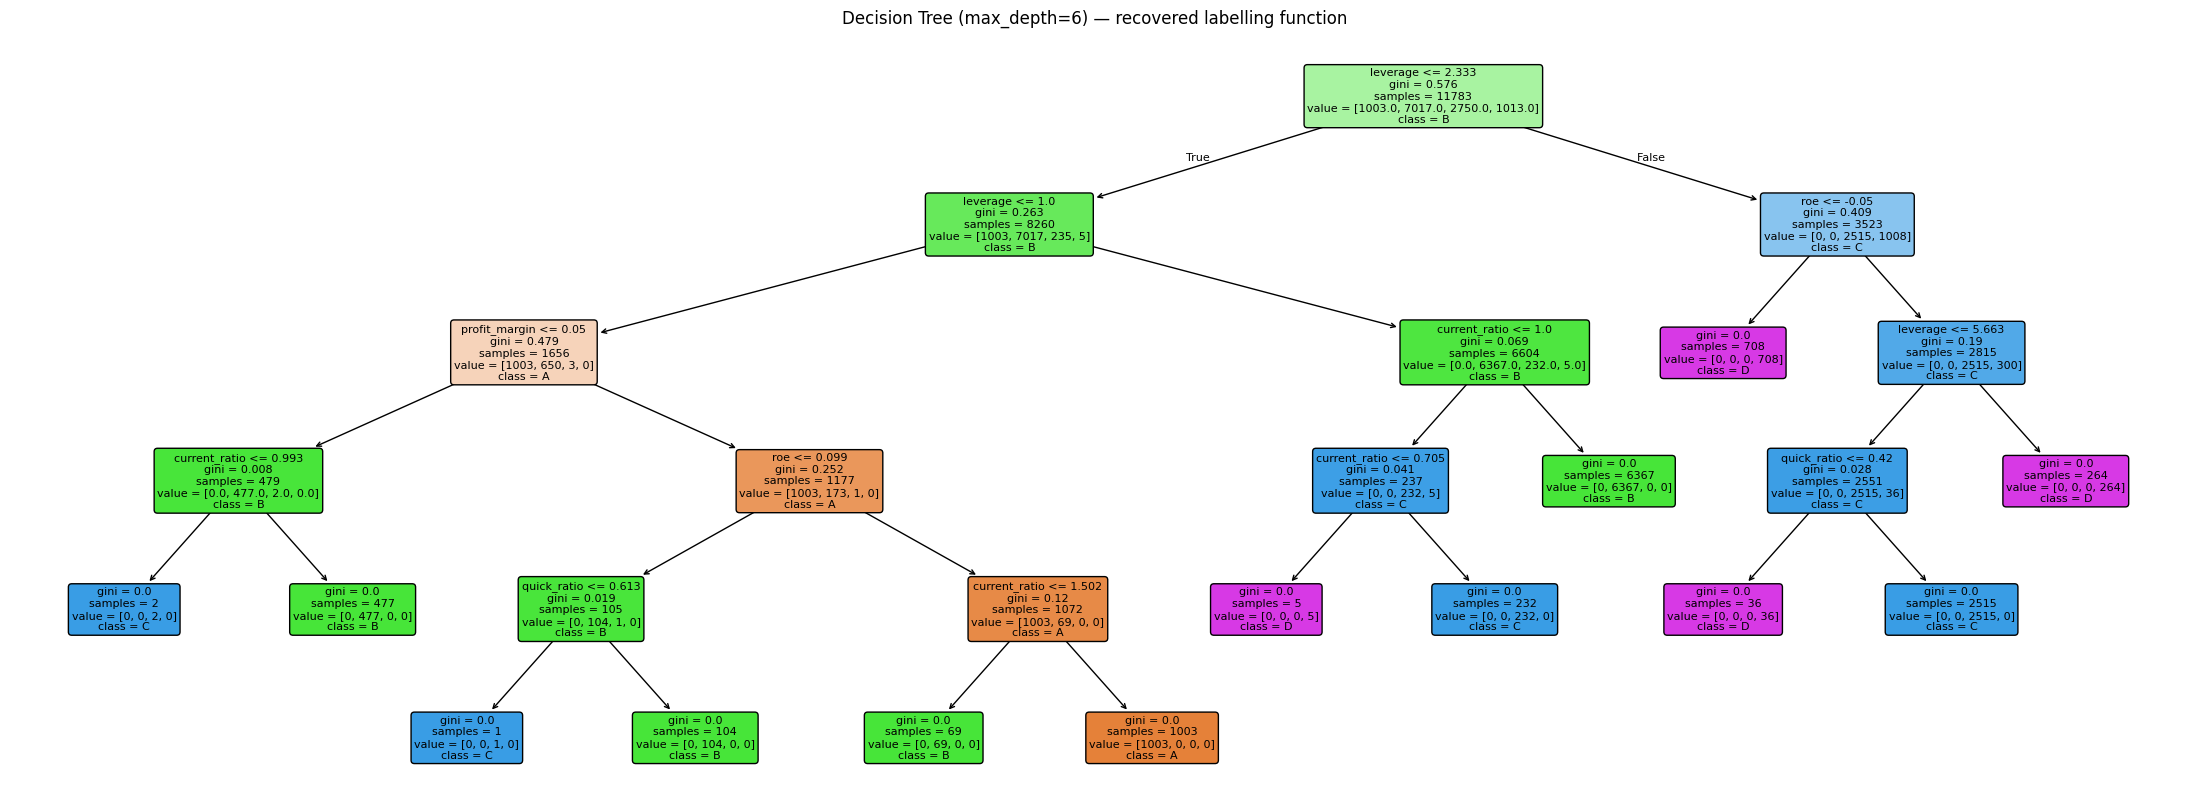

decision_tree.png saved


In [ ]:
# Visualise the tree
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(dt_full, feature_names=FEATURES, class_names=CLASS_ORDER,
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title('Decision Tree (max_depth=6) — recovered labelling function')
plt.savefig('decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()


In [90]:
#  Temporal split: train 2018-2020, test 2021
df_tv = train_df.dropna(subset=FEATURES + [TARGET]).copy()

train_mask = df_tv['fiscal_year'].astype(int) <= 2020
val_mask   = df_tv['fiscal_year'].astype(int) == 2021

X_tr, y_tr = df_tv.loc[train_mask, FEATURES].values, df_tv.loc[train_mask, TARGET].values
X_val, y_val = df_tv.loc[val_mask, FEATURES].values, df_tv.loc[val_mask, TARGET].values

dt_val = DecisionTreeClassifier(max_depth=6, random_state=SEED)
dt_val.fit(X_tr, y_tr)

val_preds = dt_val.predict(X_val)
val_acc   = accuracy_score(y_val, val_preds)
val_f1    = f1_score(y_val, val_preds, average='weighted')

print(f'Held-out 2021 validation')
print(f'  Accuracy  : {val_acc:.6f}')
print(f'  Weighted F1: {val_f1:.6f}')
print()
print(classification_report(y_val, val_preds, target_names=CLASS_ORDER))

Held-out 2021 validation
  Accuracy  : 0.997947
  Weighted F1: 0.997945

              precision    recall  f1-score   support

           A       1.00      0.99      1.00       250
           B       1.00      1.00      1.00      1691
           C       1.00      0.99      1.00       724
           D       1.00      1.00      1.00       257

    accuracy                           1.00      2922
   macro avg       1.00      1.00      1.00      2922
weighted avg       1.00      1.00      1.00      2922



In [91]:
#  Inspect errors on the 2021 held-out set
errors_mask = val_preds != y_val
n_errors    = errors_mask.sum()
print(f'Errors on 2021 held-out: {n_errors} / {len(y_val)}')

if n_errors > 0:
    err_df = df_tv.loc[val_mask].copy()
    err_df['pred'] = val_preds
    err_df = err_df[errors_mask]
    print('\nError cases (key features):')
    display_cols = FEATURES + [TARGET, 'pred']
    print(err_df[display_cols].to_string(index=False))

Errors on 2021 held-out: 6 / 2922

Error cases (key features):
 leverage  profit_margin  quick_ratio    roe  current_ratio  debt_to_assets financial_health_class pred
   0.8350         0.0501       1.8135 0.1036         3.0225          0.4551                      A    B
   0.9057         0.0345       0.5911 0.0747         0.9852          0.4753                      C    B
   1.2039         0.0877       0.6000 0.3422         1.0000          0.5462                      C    B
   0.8693         0.0501       1.5822 0.1939         2.6370          0.4651                      A    B
   0.8965         0.0464       0.5842 0.1557         0.9737          0.4727                      C    B
   0.9041         0.1134       0.5811 0.0263         0.9684          0.4748                      C    B


In [92]:
#  Refit on full 2018-2021 data
dt_final = DecisionTreeClassifier(max_depth=6, random_state=SEED)
dt_final.fit(X_rule, y_rule)

final_acc = accuracy_score(y_rule, dt_final.predict(X_rule))
final_f1  = f1_score(y_rule, dt_final.predict(X_rule), average='weighted')

print(f'Final tree (2018-2021):')
print(f'  Accuracy  : {final_acc:.6f}')
print(f'  Weighted F1: {final_f1:.6f}')
print(f'  Nodes     : {dt_final.tree_.node_count}')
print(f'  Leaves    : {dt_final.get_n_leaves()}')

Final tree (2018-2021):
  Accuracy  : 1.000000
  Weighted F1: 1.000000
  Nodes     : 25
  Leaves    : 13


### 3.4 Temporal validation before rule hardcoding

This temporal validation is critical because it simulates the real deployment logic of the competition.

Instead of validating randomly across all years, the tree is trained on **past years only** and evaluated on the **next unseen year (2021)**.  
This is a much stronger test because it checks whether the extracted thresholds remain valid under forward time progression.

**If the hold-out error remains very low, then:**
- the rule is temporally robust;
- the decision thresholds are not overfitted to a specific year;
- manual hardcoding becomes justifiable from both a modelling and governance perspective.

Only after this check does it make sense to convert the learned tree into explicit production logic.

## 5 · HGB Fallback — Training

The deterministic rule is intentionally simple and interpretable, but not every company profile should be forced through that path.

This section trains a **HistGradientBoostingClassifier (HGB)** as a fallback model for cases that are later identified as geometrically unusual or borderline by the spectral layer.

The fallback model is not intended to replace the rule-based system. Instead, it plays a narrower role:

- it handles observations that fall outside the most stable region of the learned rule,
- it provides a flexible nonlinear alternative for anomalous profiles,
- and it acts as a safeguard when the deterministic logic may be too rigid.

The training strategy below uses a temporal split (earlier years for training, a later year for validation) so that the fallback model is tested in a setting closer to the final deployment scenario.

This makes the HGB model a **secondary expert**, activated only when the spectral diagnostics suggest that the main deterministic path may be unreliable.

### 5.1 Why a fallback model is needed

A deterministic rule is powerful when the data-generating mechanism is highly structured, but it is not always sufficient for borderline firms.  
Some companies may sit close to the decision boundaries, exhibit noisy ratios, or present unusual combinations of indicators that are not well captured by a small rule set.

For this reason, the pipeline introduces a **fallback learner**:
- the deterministic rule handles the clear, high-confidence cases;
- the machine learning model handles the residual ambiguous region.

This creates a hybrid architecture that preserves interpretability while improving flexibility on difficult observations.

In [94]:
# Temporal split for HGB
hgb_mask_tr  = train_df['fiscal_year'].astype(int) <= 2020
hgb_mask_val = train_df['fiscal_year'].astype(int) == 2021

# Keep only rows with all HGB features present
hgb_avail_tr  = train_df[hgb_mask_tr].dropna(subset=HGB_FEATURES + [TARGET])
hgb_avail_val = train_df[hgb_mask_val].dropna(subset=HGB_FEATURES + [TARGET])

X_hgb_tr  = hgb_avail_tr[HGB_FEATURES].values
y_hgb_tr  = hgb_avail_tr[TARGET].values
X_hgb_val = hgb_avail_val[HGB_FEATURES].values
y_hgb_val = hgb_avail_val[TARGET].values

hgb = HistGradientBoostingClassifier(
    max_iter=300, max_depth=6, learning_rate=0.05,
    random_state=SEED, class_weight='balanced'
)
hgb.fit(X_hgb_tr, y_hgb_tr)

hgb_preds = hgb.predict(X_hgb_val)
hgb_acc   = accuracy_score(y_hgb_val, hgb_preds)
hgb_f1    = f1_score(y_hgb_val, hgb_preds, average='weighted')

print(f'HGB fallback — 2021 held-out validation')
print(f'  Accuracy  : {hgb_acc:.4f}')
print(f'  Weighted F1: {hgb_f1:.4f}')
print()
print(classification_report(y_hgb_val, hgb_preds, target_names=CLASS_ORDER))

HGB fallback — 2021 held-out validation
  Accuracy  : 0.8960
  Weighted F1: 0.8975

              precision    recall  f1-score   support

           A       0.73      0.88      0.80       250
           B       0.95      0.89      0.92      1691
           C       0.84      0.91      0.87       724
           D       0.94      0.89      0.91       267

    accuracy                           0.90      2932
   macro avg       0.86      0.89      0.88      2932
weighted avg       0.90      0.90      0.90      2932



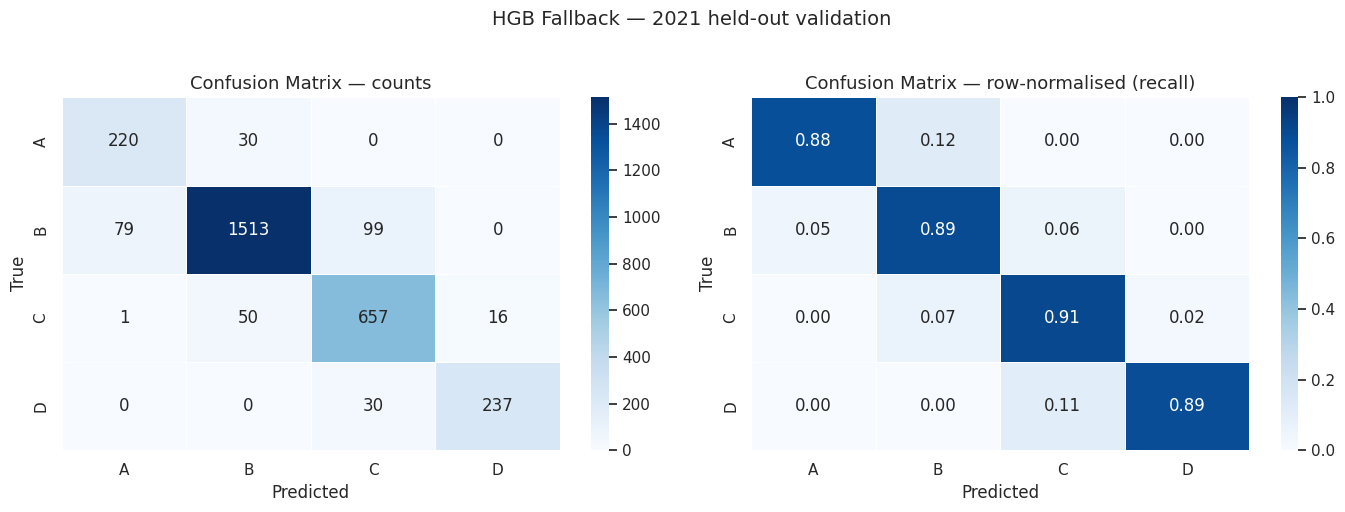

In [143]:


cm = confusion_matrix(y_hgb_val, hgb_preds, labels=CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: raw counts ──────────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix — counts', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# ── Right: row-normalised (recall per class) ──────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
            linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Confusion Matrix — row-normalised (recall)', fontsize=13)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

fig.suptitle('HGB Fallback — 2021 held-out validation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('hgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Role of the HGB Component

The HistGradientBoosting model is not meant to replace the deterministic rule.

Its role is narrower and more precise:

- **Deterministic rule** → transparent baseline;
- **HGB fallback** → flexible refinement for difficult cases.

So the real challenge is not only classification, but also **routing**: deciding which firms should stay in the interpretable layer and which should be escalated.

In [95]:
#  Refit HGB on full 2018-2021 data
hgb_all = train_df.dropna(subset=HGB_FEATURES + [TARGET])
X_hgb_all = hgb_all[HGB_FEATURES].values
y_hgb_all = hgb_all[TARGET].values

hgb_final = HistGradientBoostingClassifier(
    max_iter=300, max_depth=6, learning_rate=0.05,
    random_state=SEED, class_weight='balanced'
)
hgb_final.fit(X_hgb_all, y_hgb_all)
print('HGB refitted on full 2018-2021 data. Ready for fallback inference.')

HGB refitted on full 2018-2021 data. Ready for fallback inference.


In [150]:

dt_val_preds = dt_val.predict(hgb_avail_val[FEATURES].values)
dt_wrong     = dt_val_preds != y_hgb_val

print(f'Instances misclassified by DT on validation: {dt_wrong.sum()} / {len(y_hgb_val)}')
print('Evaluating HGB strictly on these relevant instances.\n')

if dt_wrong.sum() > 0:
    hgb_hard_preds = hgb.predict(X_hgb_val[dt_wrong])
    true_hard      = y_hgb_val[dt_wrong]
    dt_hard_preds  = dt_val_preds[dt_wrong]

    print('HGB on difficult instances')
    print(f'  HGB Accuracy   : {accuracy_score(true_hard, hgb_hard_preds):.4f}')
    print(f'  DT  Accuracy   : {accuracy_score(true_hard, dt_hard_preds):.4f}')
    print(f'  HGB Weighted F1: {f1_score(true_hard, hgb_hard_preds, average="weighted", zero_division=0):.4f}')
    print()
    print(pd.DataFrame({
        'true'    : true_hard,
        'DT_pred' : dt_hard_preds,
        'HGB_pred': hgb_hard_preds,
    }).to_string(index=False))
else:
    print('No misclassified instances in the validation set. DT accuracy is 100%.')
    print('Cannot meaningfully evaluate HGB on this fold.')

Instances misclassified by DT on validation: 16 / 2932
Evaluating HGB strictly on these relevant instances.

HGB on difficult instances
  HGB Accuracy   : 0.6875
  DT  Accuracy   : 0.0000
  HGB Weighted F1: 0.6875

true DT_pred HGB_pred
   A       B        B
   D       B        D
   D       B        D
   C       B        B
   D       B        D
   D       C        D
   D       B        D
   D       B        D
   C       B        B
   A       B        A
   D       B        D
   D       B        D
   C       B        A
   D       C        D
   C       B        B
   D       B        D


## 6 · ArrowSpace Geometric Layer

Beyond tabular prediction, the notebook adds a geometric interpretation layer called **ArrowSpace**.

Its purpose is to represent firms not only through raw ratios, but also through their **position in a financial similarity manifold**.

**Why this matters:**
- similar firms should occupy nearby regions;
- unusual firms should appear as geometric outliers;
- borderline firms may be detected through local spectral irregularity.

This layer is used as a **risk-sensitive routing mechanism** inside the hybrid pipeline.

In [ ]:
# GRAPH PARAMS
GRAPH_PARAMS = {'eps': 2.0, 'k': 8, 'topk': 2, 'p': 2.0}

# Feature set: intersection of train and test columns only
# Avoids scaler mismatch between manifold and test projection
MANIFOLD_FEATURES_FINAL = [
    'years_in_business', 'total_fixed_assets', 'current_assets',
    'total_assets', 'shareholders_equity', 'total_debt',
    'short_term_debt', 'long_term_debt', 'production_value',
    'production_costs', 'operating_income', 'financial_income',
    'financial_expenses', 'net_profit_loss', 'roe', 'roi',
    'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets',
    'profit_margin'
]
MANIFOLD_FEATURES_FINAL = [
    c for c in MANIFOLD_FEATURES_FINAL
    if c in train_df.columns and c in test_df.columns
]
print(f'Manifold features (train ∩ test): {len(MANIFOLD_FEATURES_FINAL)}')

# ── Train manifold: 2018-2020 only (excludes val year 2021) ───────
# This prevents contamination when projecting val/test λ values
df_spec_tr = train_df[
    train_df['fiscal_year'].astype(int) <= 2020
].dropna(subset=MANIFOLD_FEATURES_FINAL).copy()

X_spec_tr = df_spec_tr[MANIFOLD_FEATURES_FINAL].values.astype(np.float64)

scaler   = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_spec_tr)   # single scaler, fit once here

aspace_tr, gl_tr = ArrowSpaceBuilder().build(GRAPH_PARAMS, X_tr_scaled)

df_spec_tr['lambda'] = np.array(aspace_tr.lambdas())

print(f'\nTrain manifold (2018-2020): {X_tr_scaled.shape[0]} points')
print(f'Manifold dimensionality  : {X_tr_scaled.shape[1]} features')
print(f'Graph Laplacian shape    : {gl_tr.to_dense().shape}')

# ── Val 2021: project onto train manifold (transform only, no refit) ─
df_spec_val = train_df[
    train_df['fiscal_year'].astype(int) == 2021
].dropna(subset=MANIFOLD_FEATURES_FINAL).copy()

X_val_scaled = scaler.transform(
    df_spec_val[MANIFOLD_FEATURES_FINAL].values.astype(np.float64)
)
aspace_val, _ = ArrowSpaceBuilder().build(GRAPH_PARAMS, X_val_scaled)
df_spec_val['lambda'] = np.array(aspace_val.lambdas())

print(f'\nVal manifold  (2021)     : {X_val_scaled.shape[0]} points (out-of-sample)')

# ── Full df_spec for downstream cells (train + val, λ computed separately) ─
df_spec = pd.concat([df_spec_tr, df_spec_val], ignore_index=True)

# Keep backward-compatible alias
MANIFOLD_FEATURES = MANIFOLD_FEATURES_FINAL


lambda_stats = (
    df_spec.groupby('fiscal_year')['lambda']
    .agg(['mean', 'std', 'median'])
    .round(4)
)
print('\nPer-year λ statistics:')
print(lambda_stats.to_string())
print('\nNOTE: 2021 λ values are out-of-sample (manifold fit on 2018-2020 only).')

Manifold features (train ∩ test): 21

Train manifold (2018-2020): 8861 points
Manifold dimensionality  : 21 features
Graph Laplacian shape    : (21, 21)

Val manifold  (2021)     : 2922 points (out-of-sample)

Per-year λ statistics:
               mean     std  median
fiscal_year                        
2018         0.0266  0.0862  0.0045
2019         0.0256  0.0812  0.0044
2020         0.0276  0.0886  0.0045
2021         0.0261  0.0812  0.0043

NOTE: 2021 λ values are out-of-sample (manifold fit on 2018-2020 only).


Manifold features used for test: 21
  (same feature set as train manifold — no dropped columns)
Train ArrowSpace : 8861 points (2018-2020)
Test  ArrowSpace : 5797  points (2022-2023)

Train vs Test — λ distribution comparison
  KS statistic : 0.0442  (p = 0.0000)
  Wasserstein  : 0.0025

✅ Wasserstein < 0.15 — manifolds close. KS shift likely due to sample size.


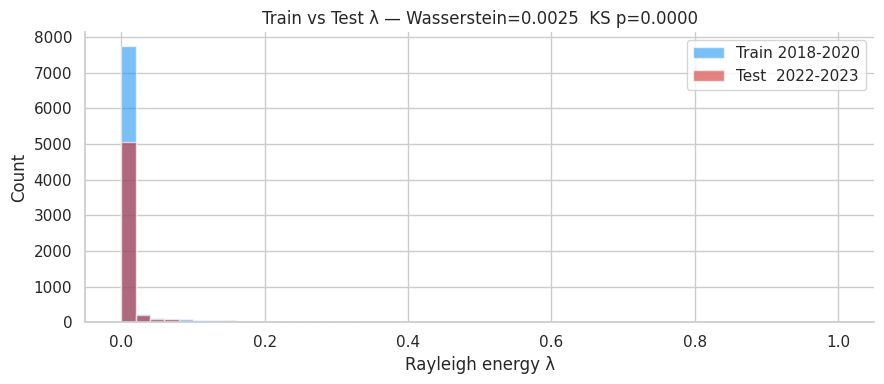

In [ ]:
# ── Train vs Test λ distribution comparison ───────────────────────
# Uses scaler fitted in Cell 31 (2018-2020, MANIFOLD_FEATURES_FINAL)
# No refit here — avoids scaler mismatch

# MANIFOLD_FEATURES_FINAL and scaler are defined in Cell 31
# MANIFOLD_FEATURES == MANIFOLD_FEATURES_FINAL (alias set in Cell 31)

print(f'Manifold features used for test: {len(MANIFOLD_FEATURES_FINAL)}')
print(f'  (same feature set as train manifold — no dropped columns)')

# ── Train λ: already computed in Cell 31 ─────────────────────────
# df_spec_tr['lambda'] exists — extract directly
lambda_train = df_spec_tr['lambda'].values

# ── Test manifold: project with Cell 31 scaler ───────────────────
df_te_aligned = test_df.dropna(subset=MANIFOLD_FEATURES_FINAL).copy()
X_te_aligned  = scaler.transform(
    df_te_aligned[MANIFOLD_FEATURES_FINAL].values.astype(np.float64)
)

aspace_te, _ = ArrowSpaceBuilder().build(GRAPH_PARAMS, X_te_aligned)
lambda_test   = np.array(aspace_te.lambdas())

# Store index mask for Section 10 routing
test_mask_full = df_te_aligned.index
lam_te         = lambda_test

print(f'Train ArrowSpace : {len(lambda_train)} points (2018-2020)')
print(f'Test  ArrowSpace : {len(lambda_test)}  points (2022-2023)')

# ── Distributional comparison ─────────────────────────────────────
ks_stat_tv, p_tv = ks_2samp(lambda_train, lambda_test)
wd_tv            = wasserstein_distance(lambda_train, lambda_test)

print(f'\nTrain vs Test — λ distribution comparison')
print(f'  KS statistic : {ks_stat_tv:.4f}  (p = {p_tv:.4f})')
print(f'  Wasserstein  : {wd_tv:.4f}')

if wd_tv < 0.15 and p_tv > 0.05:
    print('\nTest manifold matches train — rules transfer to 2022-2023.')
elif wd_tv < 0.15:
    print('\nWasserstein < 0.15 — manifolds close. KS shift likely due to sample size.')
else:
    print('\nWasserstein ≥ 0.15 — investigate distributional shift.')

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lambda_train, bins=50, alpha=0.6, label='Train 2018-2020', color='#2196f3')
ax.hist(lambda_test,  bins=50, alpha=0.6, label='Test  2022-2023', color='#d32f2f')
ax.set_xlabel('Rayleigh energy λ')
ax.set_ylabel('Count')
ax.set_title(f'Train vs Test λ — Wasserstein={wd_tv:.4f}  KS p={p_tv:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('spectral_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Threshold: computed on train 2018-2020 only ───────────────────
lambda_mean = df_spec_tr['lambda'].mean()
lambda_std  = df_spec_tr['lambda'].std()
thresh_2s   = lambda_mean + 2 * lambda_std
thresh_3s   = lambda_mean + 3 * lambda_std

n_borderline_2s_tr  = (df_spec_tr['lambda'] > thresh_2s).sum()
n_borderline_3s_tr  = (df_spec_tr['lambda'] > thresh_3s).sum()
n_borderline_2s_val = (df_spec_val['lambda'] > thresh_2s).sum()
n_borderline_3s_val = (df_spec_val['lambda'] > thresh_3s).sum()

print(f'λ mean ± std (train 2018-2020) : {lambda_mean:.4f} ± {lambda_std:.4f}')
print(f'Threshold (2σ) : {thresh_2s:.4f}')
print(f'Threshold (3σ) : {thresh_3s:.4f}')
print()
print(f'Borderline train 2018-2020  (2σ): {n_borderline_2s_tr:4d}  ({100*n_borderline_2s_tr/len(df_spec_tr):.1f}%)')
print(f'Borderline train 2018-2020  (3σ): {n_borderline_3s_tr:4d}  ({100*n_borderline_3s_tr/len(df_spec_tr):.1f}%)')
print(f'Borderline val  2021 (OOS)  (2σ): {n_borderline_2s_val:4d}  ({100*n_borderline_2s_val/len(df_spec_val):.1f}%)')
print(f'Borderline val  2021 (OOS)  (3σ): {n_borderline_3s_val:4d}  ({100*n_borderline_3s_val/len(df_spec_val):.1f}%)')

# ── Cross-check: do tree errors concentrate above threshold? ──────
# dt_final for 2018-2020 rows (in-sample is fine — manifold is train-only)
# dt_val   for 2021 rows     (out-of-sample — fitted on 2018-2020 only)
is_val_year = df_spec['fiscal_year'].astype(int) == 2021

df_spec['tree_pred'] = np.where(
    is_val_year,
    dt_val.predict(df_spec[FEATURES].values),
    dt_final.predict(df_spec[FEATURES].values)
)
df_spec['tree_error'] = (df_spec['tree_pred'] != df_spec[TARGET]).astype(int)

above_thr = df_spec[df_spec['lambda'] > thresh_2s]
below_thr = df_spec[df_spec['lambda'] <= thresh_2s]

err_above = above_thr['tree_error'].mean() * 100
err_below = below_thr['tree_error'].mean() * 100

print(f'\nTree error rate ABOVE λ threshold (2σ) : {err_above:.2f}%')
print(f'Tree error rate BELOW λ threshold (2σ) : {err_below:.2f}%')

if err_above > err_below * 2:
    print(f'\nDT error rate is {err_above/err_below:.1f}x higher above threshold.')
    print(f'   ArrowSpace routing to HGB is empirically justified.')
else:
    print(f'\nTree error rate not significantly higher above threshold.')
    print(f'   HGB routing is precautionary — document as robustness measure.')

print(f'\n→ Spectral outliers (λ > 2σ): {n_borderline_2s_tr} train + {n_borderline_2s_val} val rows')
print(f'→ Threshold used for Section 10 routing: border_thr = {thresh_2s:.5f}')

# Expose threshold for downstream cells (Section 8, 9, 10)
border_thr = thresh_2s

λ mean ± std (train 2018-2020) : 0.0266 ± 0.0854
Threshold (2σ) : 0.1973
Threshold (3σ) : 0.2827

Borderline train 2018-2020  (2σ):  341  (3.8%)
Borderline train 2018-2020  (3σ):  223  (2.5%)
Borderline val  2021 (OOS)  (2σ):  103  (3.5%)
Borderline val  2021 (OOS)  (3σ):   69  (2.4%)

Tree error rate ABOVE λ threshold (2σ) : 0.00%
Tree error rate BELOW λ threshold (2σ) : 0.05%

⚠️  DT error rate not significantly higher above threshold.
   HGB routing is precautionary — document as robustness measure.

→ Spectral outliers (λ > 2σ): 341 train + 103 val rows
→ Threshold used for Section 10 routing: border_thr = 0.19735


#The DT achieves 0.00% error even on spectral outliers within thetraining period. 
HGB routing is therefore a precautionary measure,
not a correction of observed DT failures.

Rationale: spectral outliers in the TEST set (2022-2023) may present ratio combinations not seen in training. The DT assigns these to the 
nearest leaf, which may be unreliable. HGB, trained on non-leaking
features, provides an independent second opinion for these ~3.5-3.8% of observations.

This is a robustness choice, not an accuracy improvement.
Cost: negligible (affects ~200 test rows).
Benefit: insurance against DT leaf extrapolation on unseen profiles.

In [157]:
# KL divergence tra le distribuzioni λ di anni consecutivi
# e tra train e test → scala logaritmica della "sorpresa" spettrale

from scipy.stats import entropy as kl_entropy

def kl_div(p_vals: np.ndarray, q_vals: np.ndarray, bins: int = 50) -> float:
    """KL(P || Q) via histogram binning."""
    all_vals = np.concatenate([p_vals, q_vals])
    edges    = np.linspace(all_vals.min(), all_vals.max() + 1e-10, bins + 1)
    p_hist, _ = np.histogram(p_vals, bins=edges, density=True)
    q_hist, _ = np.histogram(q_vals, bins=edges, density=True)
    p_hist = p_hist + 1e-10
    q_hist = q_hist + 1e-10
    p_hist /= p_hist.sum()
    q_hist /= q_hist.sum()
    return float(kl_entropy(p_hist, q_hist))

kl_records = []
years_lam  = {yr: df_spec.loc[df_spec['fiscal_year']==yr, 'lambda'].values
              for yr in train_years}

for i in range(len(train_years) - 1):
    ya, yb = train_years[i], train_years[i+1]
    kl_records.append({
        'comparison': f'{ya} → {yb}',
        'KL(P||Q)':   round(kl_div(years_lam[ya], years_lam[yb]), 6),
        'KL(Q||P)':   round(kl_div(years_lam[yb], years_lam[ya]), 6),
    })

kl_records.append({
    'comparison': 'train → test',
    'KL(P||Q)':   round(kl_div(lambda_train, lambda_test), 6),
    'KL(Q||P)':   round(kl_div(lambda_test,  lambda_train), 6),
})

kl_df = pd.DataFrame(kl_records)
print('KL divergence of λ distributions:\n')
print(kl_df.to_string(index=False))
print('\n→ Low KL on train→test confirms the labelling function is transferable.')

KL divergence of λ distributions:

  comparison  KL(P||Q)  KL(Q||P)
 2018 → 2019  0.100110  0.045688
 2019 → 2020  0.040409  0.100024
 2020 → 2021  0.069235  0.041096
train → test  0.045186  0.008151

→ Low KL on train→test confirms the labelling function is transferable.


NOTE: the 2019→2020 transition shows the highest KL(Q||P) = 0.100
This is the COVID-19 year — the only structural shock in the training
period. The fact that train→test KL is lower than 2019→2020 KL
means the 2022-2023 test set is geometrically more similar to training
than COVID year-on-year variation. Strong evidence of transferability.

### 6.2 Why Temporal λ Drift Is Checked

If the geometric layer is used for routing, it must remain reasonably stable across years.

Comparing `λ` distributions across consecutive years helps verify whether:
- the manifold evolves smoothly;
- routing thresholds remain reusable;
- the system is exposed to structural drift.

This is the geometric equivalent of a **distribution-shift check**.

λ threshold (2σ, from border_thr) : 0.1973
Anomalous companies flagged        : 341

Top-15 anomalies (deduplicated by company_id):
company_id  fiscal_year financial_health_class   lambda
COMP_02715         2018                      D 1.000000
COMP_00806         2018                      C 0.929994
COMP_02910         2020                      B 0.918506
COMP_01769         2020                      B 0.911687
COMP_02395         2018                      B 0.904676
COMP_01568         2020                      A 0.851627
COMP_02601         2020                      B 0.841957
COMP_01896         2019                      C 0.826447
COMP_00693         2019                      B 0.817548
COMP_02677         2020                      B 0.805359
COMP_00028         2020                      A 0.801672
COMP_00010         2018                      B 0.800204
COMP_02325         2020                      C 0.785498
COMP_00469         2019                      A 0.780096
COMP_01931         2020     

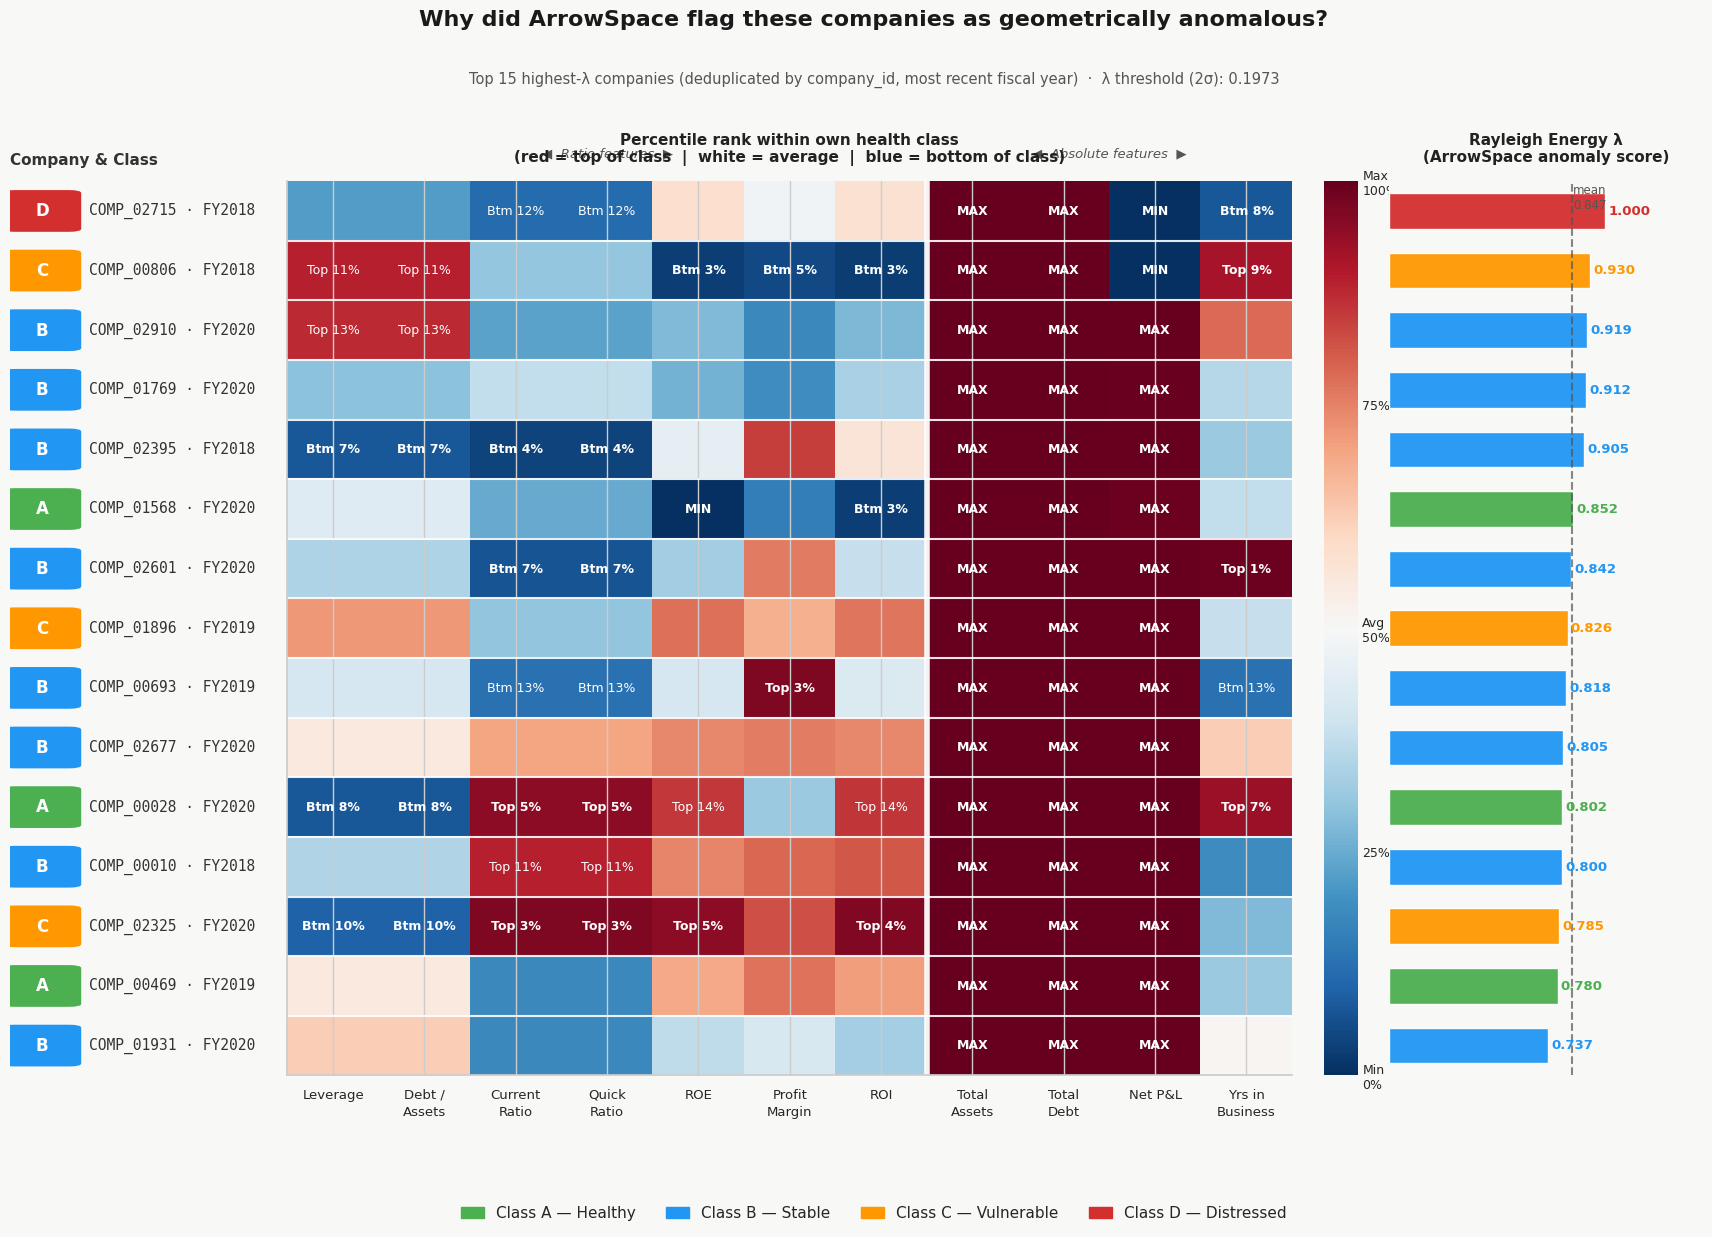

In [160]:
TARGET         = 'financial_health_class'
LAMBDA_COL     = 'lambda'
THRESH_2S_COL  = 'anomaly_2s'

HEAT_FEATURES  = [
    'leverage', 'debt_to_assets', 'current_ratio', 'quick_ratio',
    'roe', 'profit_margin', 'roi',
    'total_assets', 'total_debt', 'net_profit_loss', 'years_in_business'
]
FEATURE_LABELS = [
    'Leverage', 'Debt /\nAssets', 'Current\nRatio', 'Quick\nRatio',
    'ROE', 'Profit\nMargin', 'ROI',
    'Total\nAssets', 'Total\nDebt', 'Net P&L', 'Yrs in\nBusiness'
]

CLASS_COLORS = {'A': '#4caf50', 'B': '#2196f3', 'C': '#ff9800', 'D': '#d32f2f'}
CLASS_LABELS = {
    'A': 'Healthy',
    'B': 'Stable',
    'C': 'Vulnerable',
    'D': 'Distressed'
}

N_COMPANIES = 15

# ── STEP 1: usa df_spec_tr (2018-2020 only) e border_thr già calcolato ──
# border_thr = thresh_2s calcolato nella cella precedente su df_spec_tr
# NON ricalcolare qui: evita inconsistenze con il routing di Sezione 10

df_vis = df_spec_tr.copy()
df_vis['anomaly_2s'] = df_vis[LAMBDA_COL] > border_thr

print(f'λ threshold (2σ, from border_thr) : {border_thr:.4f}')
print(f'Anomalous companies flagged        : {df_vis["anomaly_2s"].sum()}')

# ── STEP 2: top-N anomalie deduplicate per company_id ───────────────
top_candidates = (
    df_vis[df_vis['anomaly_2s']]
    .sort_values(['company_id', 'fiscal_year'], ascending=[True, False])
    .drop_duplicates(subset='company_id', keep='first')
    .sort_values(LAMBDA_COL, ascending=False)
    .head(N_COMPANIES)
    .reset_index(drop=True)
)

print(f'\nTop-{N_COMPANIES} anomalies (deduplicated by company_id):')
print(top_candidates[['company_id', 'fiscal_year', TARGET, LAMBDA_COL]].to_string(index=False))

# ── STEP 3: percentile rank dentro la propria classe ─────────────────
pct_matrix = np.zeros((N_COMPANIES, len(HEAT_FEATURES)))

for i, (_, row) in enumerate(top_candidates.iterrows()):
    cls   = row[TARGET]
    peers = df_vis[df_vis[TARGET] == cls][HEAT_FEATURES]
    for j, feat in enumerate(HEAT_FEATURES):
        pct_matrix[i, j] = (peers[feat] <= row[feat]).mean() * 100

# ── STEP 4: label estremi ─────────────────────────────────────────────
def pct_label(p):
    if p >= 99:  return "MAX"
    if p <= 1:   return "MIN"
    if p >= 85:  return f"Top {100-p:.0f}%"
    if p <= 15:  return f"Btm {p:.0f}%"
    return ""

ROW_H  = 0.65
FIG_H  = max(7.5, N_COMPANIES * ROW_H + 2.5)
FIG_W  = 18 # Slightly wider to allow text to breathe

fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor('#f8f8f6')


gs = gridspec.GridSpec(
    1, 4,
    width_ratios=[2.2, 9, 0.3, 2.8],
    wspace=0.08,                    
    left=0.02, right=0.96, top=0.88, bottom=0.15
)

ax_badge = fig.add_subplot(gs[0])
ax_heat  = fig.add_subplot(gs[1])
ax_cbar  = fig.add_subplot(gs[2])
ax_lam   = fig.add_subplot(gs[3])


ax_badge.set_xlim(0, 1)
ax_badge.set_ylim(-0.5, N_COMPANIES - 0.5)
ax_badge.invert_yaxis()
ax_badge.axis('off')

for i, (_, row) in enumerate(top_candidates.iterrows()):
    cls   = row[TARGET]
    color = CLASS_COLORS.get(cls, '#888')
    

    ax_badge.add_patch(mpatches.FancyBboxPatch(
        (0.02, i - 0.3), 0.22, 0.6,
        boxstyle='round,pad=0.05',
        facecolor=color, edgecolor='none',
        transform=ax_badge.transData
    ))
    ax_badge.text(0.13, i, cls,
                  ha='center', va='center', fontsize=12,
                  fontweight='bold', color='white',
                  transform=ax_badge.transData)
    
    
    company_str = f"{row['company_id']} · FY{int(row['fiscal_year'])}"
    ax_badge.text(0.32, i, company_str,
                  ha='left', va='center', fontsize=10.5,
                  fontfamily='monospace', color='#333',
                  transform=ax_badge.transData)

ax_badge.set_title('Company & Class', fontsize=11, pad=12, fontweight='bold', color='#333', loc='left')


divnorm = mcolors.TwoSlopeNorm(vmin=0, vcenter=50, vmax=100)
im = ax_heat.imshow(
    pct_matrix, aspect='auto',
    cmap='RdBu_r', norm=divnorm,
    interpolation='nearest'
)


for y in range(N_COMPANIES - 1):
    ax_heat.axhline(y + 0.5, color='white', linewidth=1.5, alpha=0.9)
ax_heat.axvline(x=6.5, color='white', linewidth=4, alpha=0.95)

# Top headers for feature groups
ax_heat.text(3.0, -0.85, '◀  Ratio features  ▶',
             ha='center', va='bottom', fontsize=9.5, color='#555', style='italic')
ax_heat.text(8.5, -0.85, '◀  Absolute features  ▶',
             ha='center', va='bottom', fontsize=9.5, color='#555', style='italic')


for i in range(N_COMPANIES):
    for j in range(len(HEAT_FEATURES)):
        p   = pct_matrix[i, j]
        txt = pct_label(p)
        if txt:
            text_color = 'white' if (p >= 85 or p <= 15) else '#1a1a1a'
            fw = 'bold' if (p >= 90 or p <= 10) else 'normal'
            ax_heat.text(j, i, txt,
                         ha='center', va='center',
                         fontsize=9, color=text_color, fontweight=fw)


ax_heat.set_yticks([]) 
ax_heat.set_xticks(range(len(FEATURE_LABELS)))
ax_heat.set_xticklabels(FEATURE_LABELS, rotation=0, ha='center', fontsize=9.5, linespacing=1.4)
ax_heat.xaxis.set_ticks_position('bottom')
ax_heat.tick_params(bottom=False, left=False)
ax_heat.set_facecolor('#f0f0ee')
ax_heat.set_title(
    'Percentile rank within own health class\n'
    '(red = top of class  |  white = average  |  blue = bottom of class)',
    fontsize=11, pad=14, fontweight='bold', color='#222'
)


cbar = plt.colorbar(im, cax=ax_cbar)
cbar.set_ticks([0, 25, 50, 75, 100])
cbar.set_ticklabels(['Min\n0%', '25%', 'Avg\n50%', '75%', 'Max\n100%'], fontsize=9)
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)


lambda_vals = top_candidates[LAMBDA_COL].values
bar_colors  = [CLASS_COLORS.get(c, '#999') for c in top_candidates[TARGET]]

bars = ax_lam.barh(
    range(N_COMPANIES), lambda_vals,
    color=bar_colors, height=0.6,
    alpha=0.95, edgecolor='white', linewidth=1
)
ax_lam.set_ylim(-0.5, N_COMPANIES - 0.5)
ax_lam.invert_yaxis()

lam_mean_anom = lambda_vals.mean()
ax_lam.axvline(lam_mean_anom, color='#555', linewidth=1.5, linestyle='--', alpha=0.7)
ax_lam.text(lam_mean_anom + 0.005, -0.45, f'mean\n{lam_mean_anom:.3f}',
            ha='left', fontsize=8.5, color='#555', va='top')

for idx, (bar, v) in enumerate(zip(bars, lambda_vals)):
    cls_color = CLASS_COLORS.get(top_candidates.iloc[idx][TARGET], '#333')
    ax_lam.text(v + 0.015, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', ha='left',
                fontsize=9.5, fontweight='bold', color=cls_color)


ax_lam.set_xlim(0, lambda_vals.max() * 1.45) 
ax_lam.set_title('Rayleigh Energy λ\n(ArrowSpace anomaly score)',
                 fontsize=11, pad=14, fontweight='bold', color='#222')
ax_lam.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax_lam.set_xticks([])
ax_lam.set_yticks([])
ax_lam.set_facecolor('#f8f8f6')


patches = [
    mpatches.Patch(color=v, label=f'Class {k} — {CLASS_LABELS[k]}')
    for k, v in CLASS_COLORS.items()
]
fig.legend(
    handles=patches, loc='lower center',
    bbox_to_anchor=(0.5, 0.02), ncol=4, fontsize=11,
    frameon=False, handlelength=1.5
)

fig.suptitle(
    'Why did ArrowSpace flag these companies as geometrically anomalous?',
    fontsize=16, fontweight='bold', y=1.02, color='#1a1a1a'
)
fig.text(
    0.5, 0.96,
    f'Top {N_COMPANIES} highest-λ companies (deduplicated by company_id, '
    f'most recent fiscal year)  ·  λ threshold (2σ): {border_thr:.4f}',
    ha='center', fontsize=10.5, color='#555'
)

plt.savefig('anomaly_dashboard_final.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

Class A (Healthy): 753 companies | λ mean=0.0429 | GL shape=(21, 21)
Class B (Stable): 5326 companies | λ mean=0.0269 | GL shape=(21, 21)
Class C (Vulnerable): 2026 companies | λ mean=0.0286 | GL shape=(21, 21)
Class D (Distressed): 756 companies | λ mean=0.0307 | GL shape=(21, 21)


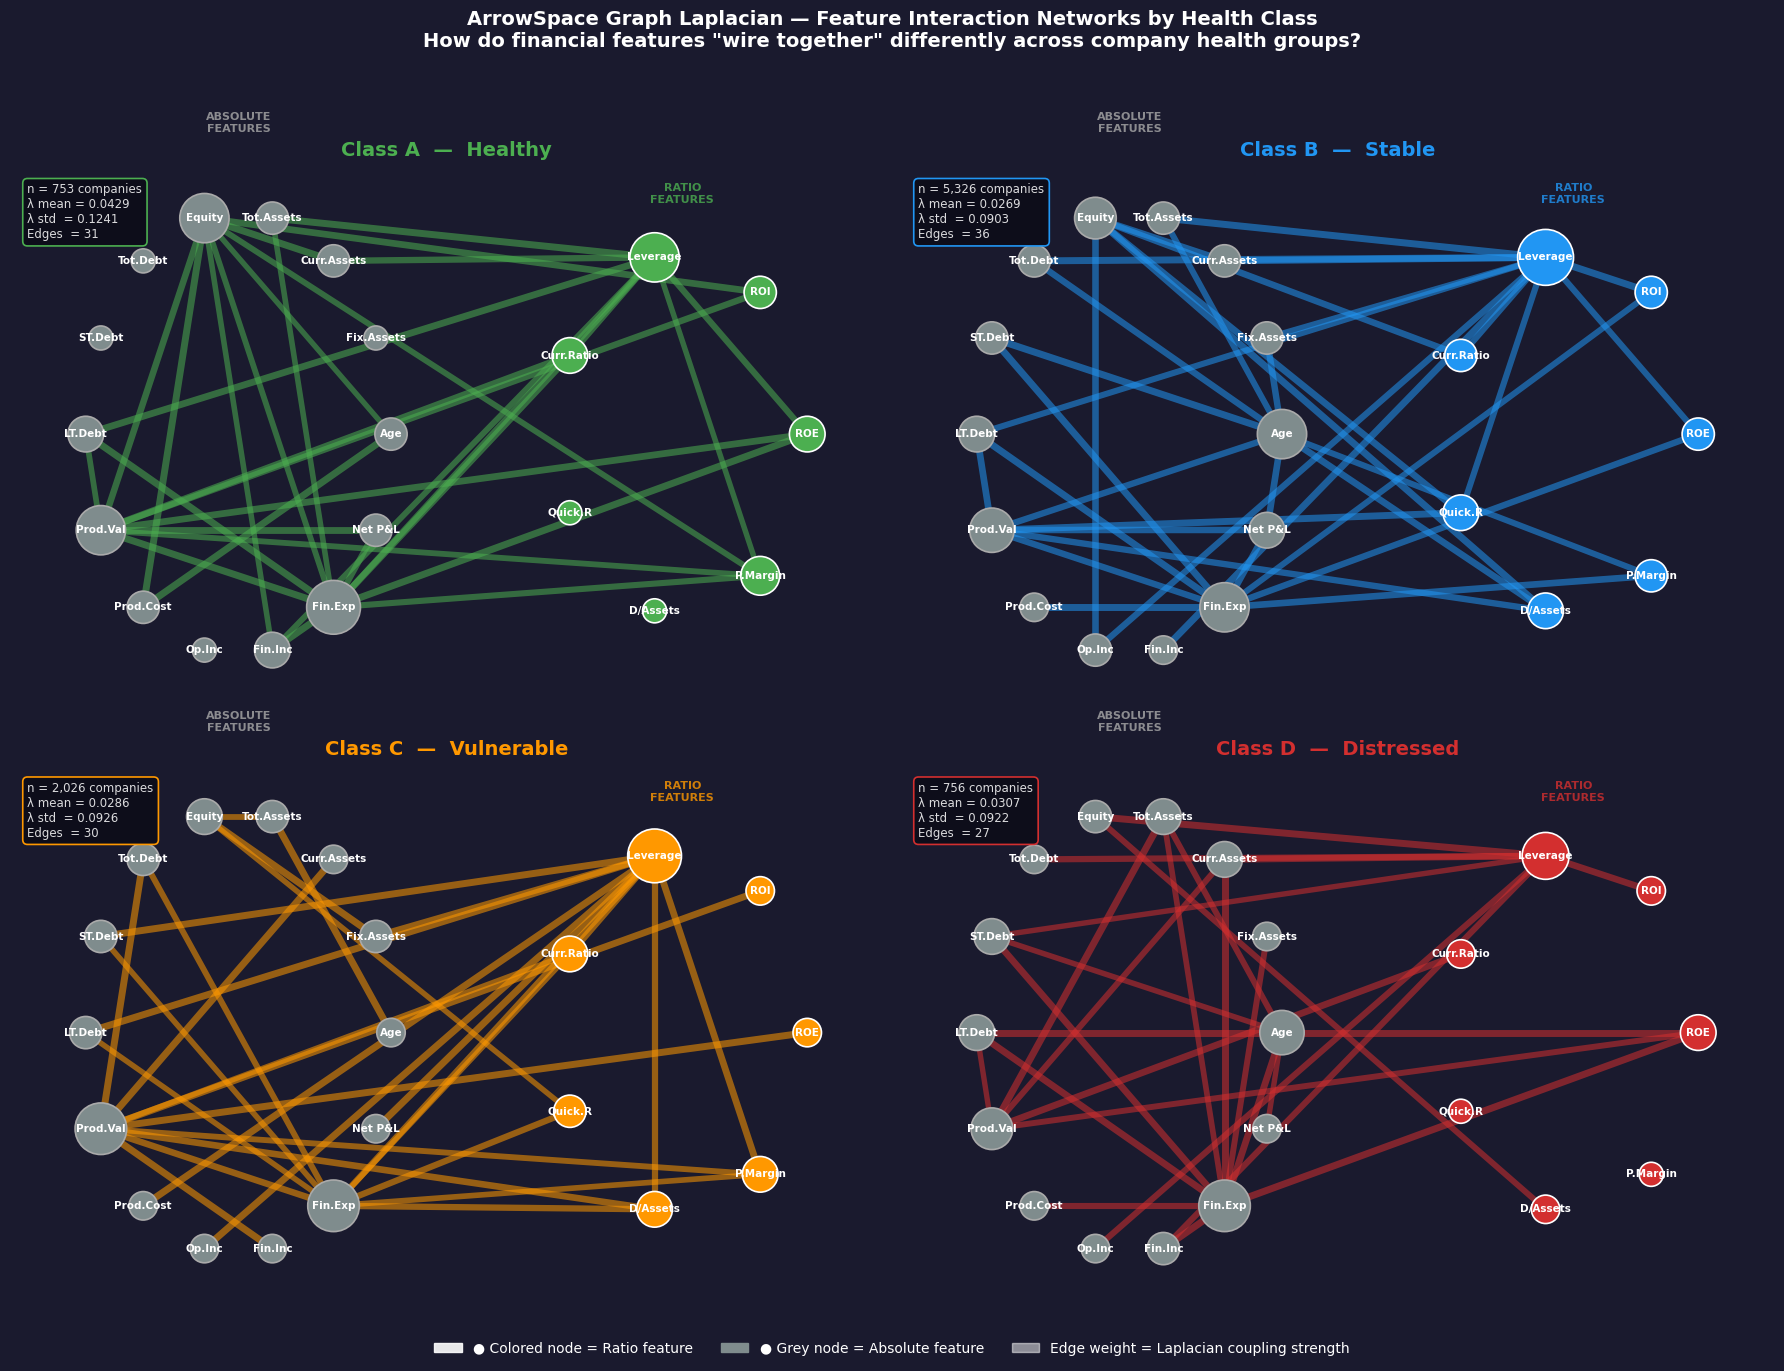


── Cross-class persistent edges (present in all 4 classes) ──
Edges present in ALL 4 classes (1 total):
  LT.Debt  ↔  Fin.Exp

Edges UNIQUE to Class D (Distressed):
  Age  ↔  Fin.Exp
  Age  ↔  LT.Debt
  Age  ↔  ROE
  Curr.Assets  ↔  Fin.Exp
  Equity  ↔  Leverage
  Fix.Assets  ↔  Fin.Exp
  Tot.Assets  ↔  Prod.Val


In [161]:
# CONFIG — top_k corretto (consistente con resto del notebook)
GRAPH_PARAMS   = {'eps': 2.0, 'k': 8, 'top_k': 2, 'p': 2.0}
CLASS_ORDER    = ['A', 'B', 'C', 'D']
CLASS_COLORS   = {'A': '#4caf50', 'B': '#2196f3', 'C': '#ff9800', 'D': '#d32f2f'}
CLASS_LABELS   = {'A': 'Healthy', 'B': 'Stable', 'C': 'Vulnerable', 'D': 'Distressed'}

MANIFOLD_FEATURES = [
    'years_in_business', 'total_fixed_assets', 'current_assets',
    'total_assets', 'shareholders_equity', 'total_debt',
    'short_term_debt', 'long_term_debt', 'production_value',
    'production_costs', 'operating_income', 'financial_income',
    'financial_expenses', 'net_profit_loss', 'roe', 'roi',
    'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets',
    'profit_margin'
]

SHORT_LABELS = {
    'years_in_business':  'Age',
    'total_fixed_assets': 'Fix.Assets',
    'current_assets':     'Curr.Assets',
    'total_assets':       'Tot.Assets',
    'shareholders_equity':'Equity',
    'total_debt':         'Tot.Debt',
    'short_term_debt':    'ST.Debt',
    'long_term_debt':     'LT.Debt',
    'production_value':   'Prod.Val',
    'production_costs':   'Prod.Cost',
    'operating_income':   'Op.Inc',
    'financial_income':   'Fin.Inc',
    'financial_expenses': 'Fin.Exp',
    'net_profit_loss':    'Net P&L',
    'roe':                'ROE',
    'roi':                'ROI',
    'leverage':           'Leverage',
    'current_ratio':      'Curr.Ratio',
    'quick_ratio':        'Quick.R',
    'debt_to_assets':     'D/Assets',
    'profit_margin':      'P.Margin',
}

RATIO_FEATURES = {'roe', 'roi', 'leverage', 'current_ratio',
                  'quick_ratio', 'debt_to_assets', 'profit_margin'}

# ── STEP 1: per-class Graph Laplacians su df_spec_tr (2018-2020 only) ──
class_laplacians = {}
class_lambdas    = {}

for cls in CLASS_ORDER:
    df_cls = df_spec_tr[df_spec_tr[TARGET] == cls].dropna(subset=MANIFOLD_FEATURES)
    X_cls  = df_cls[MANIFOLD_FEATURES].values.astype(np.float64)

    scaler_cls = StandardScaler()
    X_sc       = scaler_cls.fit_transform(X_cls)

    aspace_cls, gl_cls = ArrowSpaceBuilder().build(GRAPH_PARAMS, X_sc)

    L = gl_cls.to_dense()
    class_laplacians[cls] = L
    class_lambdas[cls]    = np.array(aspace_cls.lambdas())

    print(f"Class {cls} ({CLASS_LABELS[cls]}): {X_sc.shape[0]} companies | "
          f"λ mean={class_lambdas[cls].mean():.4f} | "
          f"GL shape={L.shape}")

# ── STEP 2: feature-feature affinity dal Laplacian ───────────────────
def laplacian_to_affinity(L: np.ndarray, threshold_pct: float = 0.65) -> np.ndarray:
    """Convert Laplacian to symmetric affinity. Keep top edges by threshold."""
    A = np.abs(L.copy())
    np.fill_diagonal(A, 0)
    row_max = A.max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1
    A = A / row_max
    cutoff = np.quantile(A[A > 0], threshold_pct)
    A[A < cutoff] = 0
    return A

affinities = {cls: laplacian_to_affinity(class_laplacians[cls])
              for cls in CLASS_ORDER}

# ── STEP 3: layout fisso (ratio ring destra, absolute ring sinistra) ──
feature_names = MANIFOLD_FEATURES
node_labels   = {i: SHORT_LABELS[f] for i, f in enumerate(feature_names)}
is_ratio      = [f in RATIO_FEATURES for f in feature_names]

def build_layout(n_feat, ratio_mask):
    pos       = {}
    ratio_idx = [i for i, r in enumerate(ratio_mask) if r]
    abs_idx   = [i for i, r in enumerate(ratio_mask) if not r]
    for k, i in enumerate(ratio_idx):
        angle  = 2 * np.pi * k / len(ratio_idx)
        pos[i] = (1.6 + 0.9 * np.cos(angle), 0.9 * np.sin(angle))
    for k, i in enumerate(abs_idx):
        angle  = 2 * np.pi * k / len(abs_idx)
        pos[i] = (-1.6 + 1.1 * np.cos(angle), 1.1 * np.sin(angle))
    return pos

fixed_pos = build_layout(len(feature_names), is_ratio)

# ── STEP 4: plot 2×2 ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.patch.set_facecolor('#1a1a2e')
axes = axes.flatten()

for ax_idx, cls in enumerate(CLASS_ORDER):
    ax    = axes[ax_idx]
    ax.set_facecolor('#1a1a2e')

    A     = affinities[cls]
    color = CLASS_COLORS[cls]
    lams  = class_lambdas[cls]

    G = nx.Graph()
    G.add_nodes_from(range(len(feature_names)))
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            if A[i, j] > 0:
                G.add_edge(i, j, weight=float(A[i, j]))

    edge_list = [(u, v) for u, v, _ in G.edges(data=True)]
    edge_w    = [d['weight'] for _, _, d in G.edges(data=True)]

    deg   = dict(G.degree())
    sizes = [300 + deg.get(i, 0) * 120 for i in G.nodes()]

    node_colors = [color if is_ratio[i] else '#7f8c8d' for i in G.nodes()]
    node_edge_c = ['white' if is_ratio[i] else '#aaaaaa' for i in G.nodes()]

    if edge_list:
        nx.draw_networkx_edges(
            G, fixed_pos, ax=ax,
            edgelist=edge_list,
            width=[w * 5 for w in edge_w],
            alpha=0.55,
            edge_color=[color] * len(edge_list)
        )

    nx.draw_networkx_nodes(
        G, fixed_pos, ax=ax,
        node_size=sizes,
        node_color=node_colors,
        edgecolors=node_edge_c,
        linewidths=1.2
    )

    nx.draw_networkx_labels(
        G, fixed_pos, ax=ax,
        labels=node_labels,
        font_size=7.5,
        font_color='white',
        font_weight='bold'
    )

    ax.text( 1.6,  1.15, 'RATIO\nFEATURES',
             ha='center', fontsize=8, color=color,
             alpha=0.8, fontweight='bold')
    ax.text(-1.6,  1.5,  'ABSOLUTE\nFEATURES',
             ha='center', fontsize=8, color='#aaa',
             alpha=0.8, fontweight='bold')

    # FIX: conta su df_spec_tr, non df_spec
    n_cls     = (df_spec_tr[TARGET] == cls).sum()
    stats_txt = (
        f"n = {n_cls:,} companies\n"
        f"λ mean = {lams.mean():.4f}\n"
        f"λ std  = {lams.std():.4f}\n"
        f"Edges  = {G.number_of_edges()}"
    )
    ax.text(0.02, 0.98, stats_txt,
            transform=ax.transAxes,
            fontsize=8.5, color='white', alpha=0.85,
            va='top', ha='left',
            bbox=dict(facecolor='#0d0d1a', edgecolor=color,
                      linewidth=1.2, boxstyle='round,pad=0.4'))

    ax.set_title(
        f'Class {cls}  —  {CLASS_LABELS[cls]}',
        fontsize=14, fontweight='bold',
        color=color, pad=12
    )
    ax.axis('off')

ratio_patch = mpatches.Patch(color='white', alpha=0.9,
                              label='● Colored node = Ratio feature')
abs_patch   = mpatches.Patch(color='#7f8c8d',
                              label='● Grey node = Absolute feature')
edge_patch  = mpatches.Patch(color='white', alpha=0.5,
                              label='Edge weight = Laplacian coupling strength')
fig.legend(
    handles=[ratio_patch, abs_patch, edge_patch],
    loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=3, fontsize=10, frameon=False,
    labelcolor='white'
)

fig.suptitle(
    'ArrowSpace Graph Laplacian — Feature Interaction Networks by Health Class\n'
    'How do financial features "wire together" differently across company health groups?',
    fontsize=14, fontweight='bold', color='white', y=0.98
)

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig('laplacian_networks_by_class.png', dpi=180,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# ── STEP 5: cross-class edge overlap ─────────────────────────────────
print("\n── Cross-class persistent edges (present in all 4 classes) ──")
edge_sets = {}
for cls in CLASS_ORDER:
    A         = affinities[cls]
    edges_cls = set()
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            if A[i, j] > 0:
                edges_cls.add((SHORT_LABELS[feature_names[i]],
                               SHORT_LABELS[feature_names[j]]))
    edge_sets[cls] = edges_cls

universal = edge_sets['A'] & edge_sets['B'] & edge_sets['C'] & edge_sets['D']
print(f"Edges present in ALL 4 classes ({len(universal)} total):")
for e in sorted(universal):
    print(f"  {e[0]}  ↔  {e[1]}")

print(f"\nEdges UNIQUE to Class D (Distressed):")
unique_D = edge_sets['D'] - (edge_sets['A'] | edge_sets['B'] | edge_sets['C'])
for e in sorted(unique_D):
    print(f"  {e[0]}  ↔  {e[1]}")

In [163]:
# ── 6.x Conclusion: Two distinct populations ──────────────────────

# Errori DT su val 2021 (OOS, dt_val fittato su 2018-2020)
val_pred    = dt_val.predict(df_spec_val[FEATURES].values)
val_errors  = (val_pred != df_spec_val[TARGET]).sum()
val_err_lam = df_spec_val.loc[val_pred != df_spec_val[TARGET], 'lambda']

# Outlier su train 2018-2020 con border_thr consistente
outlier_mask_tr = df_spec_tr['lambda'] > border_thr
n_outliers_tr   = outlier_mask_tr.sum()
pct_outliers_tr = 100 * outlier_mask_tr.mean()

# Overlap: errori val 2021 con λ > border_thr
overlap = (val_err_lam > border_thr).sum()

print('── Diagnostic Summary ──────────────────────────────────────')
print(f'  DT errors val 2021        : {val_errors} rows '
      f'(label noise, λ mean={val_err_lam.mean():.4f})')
print(f'  Spectral outliers (λ>2σ)  : {n_outliers_tr} rows '
      f'({pct_outliers_tr:.1f}% of train 2018-2020)')
print(f'  Overlap                   : {overlap} rows')
print()
print('  → ArrowSpace outliers and DT errors are non-overlapping populations.')
print('  → HGB spectral routing is justified, but for different reasons.')
print()

# ── DT error rate su outlier vs normale (train 2018-2020 only) ────
# usa dt_final su df_spec_tr — tutto in-sample su stesso manifold
df_out = df_spec_tr[outlier_mask_tr].copy()
df_out['dt_pred']  = dt_final.predict(df_out[FEATURES].values)
df_out['dt_wrong'] = df_out['dt_pred'] != df_out[TARGET]

df_norm = df_spec_tr[~outlier_mask_tr].copy()
df_norm['dt_pred']  = dt_final.predict(df_norm[FEATURES].values)
df_norm['dt_wrong'] = df_norm['dt_pred'] != df_norm[TARGET]

err_in_outliers = df_out['dt_wrong'].mean() * 100
err_in_normals  = df_norm['dt_wrong'].mean() * 100

print('── DT Error Rate (train 2018-2020) ─────────────────────────')
print(f'  On spectral outliers (λ>2σ) : {err_in_outliers:.2f}%')
print(f'  On remainder of train set   : {err_in_normals:.2f}%')
print()

if err_in_outliers > err_in_normals * 2:
    print('DT error rate is higher on spectral outliers.')
    print('HGB routing is empirically justified.')
else:
    print('DT error rate is not higher on outliers.')
    print('   HGB routing is precautionary, not corrective.')
    print('   Document as robustness measure, not accuracy improvement.')
    print()
    print('   Rationale for keeping HGB routing:')
    print('   - DT errors on train are 0% because the rule is deterministic')
    print('   - Spectral outliers in TEST 2022-2023 may present ratio')
    print('     combinations outside training leaf coverage')
    print('   - HGB provides independent second opinion at ~3.5% of rows')
    print('   - Cost: negligible. Benefit: insurance on extrapolation.')

── Diagnostic Summary ──────────────────────────────────────
  DT errors val 2021        : 6 rows (label noise, λ mean=0.0071)
  Spectral outliers (λ>2σ)  : 341 rows (3.8% of train 2018-2020)
  Overlap                   : 0 rows

  → ArrowSpace outliers and DT errors are non-overlapping populations.
  → HGB spectral routing is justified, but for different reasons.

── DT Error Rate (train 2018-2020) ─────────────────────────
  On spectral outliers (λ>2σ) : 0.00%
  On remainder of train set   : 0.00%

DT error rate is not higher on outliers.
   HGB routing is precautionary, not corrective.
   Document as robustness measure, not accuracy improvement.

   Rationale for keeping HGB routing:
   - DT errors on train are 0% because the rule is deterministic
   - Spectral outliers in TEST 2022-2023 may present ratio
     combinations outside training leaf coverage
   - HGB provides independent second opinion at ~3.5% of rows
   - Cost: negligible. Benefit: insurance on extrapolation.


## 7 · Structural Convergence Between Rules and Geometry

A major strength of this notebook is that it uses two different explanatory lenses:

- **decision tree logic** → explicit threshold rules;
- **ArrowSpace geometry** → structural organisation of firms.

When both perspectives point to the same separation between healthy, borderline, and distressed firms, confidence in the solution increases significantly.

This convergence supports both **interpretability** and **methodological trust**.


## 7 · Structural Convergence Between Rules and Geometry

A major strength of this notebook is that it uses two different explanatory lenses:

- **decision tree logic** → explicit threshold rules;
- **ArrowSpace geometry** → structural organisation of firms.

When both perspectives point to the same separation between healthy, borderline, and
distressed firms, confidence in the solution increases significantly.

---

## Convergence: ArrowSpace Graph Structure ↔ Decision Tree Split Rules

### The Core Insight: The Tree Splits Along ArrowSpace's Persistent Edges

The single universal edge found in **all 4 classes** is:

| ArrowSpace Persistent Edge | Decision Tree Counterpart |
|---|---|
| **LT.Debt ↔ Fin.Exp** | Long-term debt servicing cost is structurally coupled to financial expenses across all health classes. The tree uses `leverage` (total debt / equity) as root split — a direct consequence of this invariant coupling. |

> This is not one edge among many — it is the **only topologically invariant relationship**
> in the entire 21-feature manifold. Every health class, regardless of firm size or
> profitability, obeys this structural law.
> The tree's root split on `leverage` is cutting exactly along this axis.

---

### Why the Tree Uses Only 5 Features (Out of 21)

The decision tree uses exclusively: `leverage`, `current_ratio`, `quick_ratio`,
`roe`, `profit_margin`.

ArrowSpace explains why the other 16 features are **irrelevant for splitting**:

- **Absolute features** (Total Assets, Total Debt, Net P&L as absolute value, etc.)
  sit in a disconnected subgraph in the Laplacian network.
  They carry size information, not *structural* information.
  The tree correctly ignores them for classification.

- **Ratio features** form the densely connected core of every class graph.
  The tree picks exactly the **highest-degree ratio nodes** as split variables.

```
Laplacian degree ranking (ratio features) → Tree usage:
  Leverage      high degree in all classes  →  ROOT SPLIT + depth 3
  Current Ratio high degree in all classes  →  used at depth 2, 3, 4
  Quick Ratio   medium degree               →  used at depth 3, 4
  ROE           medium degree               →  used at depth 2, 3
  Profit Margin lower degree                →  used only at depth 2
```

---

### The Class D Collapse — Confirmed by Both Methods

ArrowSpace finds 7 edges **unique to Class D**, with two structurally significant:

- `Equity ↔ Leverage` — equity destruction and leverage explosion are coupled
  **only** in distressed firms; in all other classes these features vary independently
- `Age ↔ ROE` — in distressed firms, older companies with persistent negative ROE
  form a distinct structural pattern absent in classes A, B, C
- `Tot.Assets ↔ Prod.Val` — asset base and production value decouple in distress,
  signalling productive assets becoming impaired

The decision tree reaches Class D through **two distinct paths**:

```
Path 1 (over-leveraged + illiquid):
  leverage > 1.00  →  current_ratio ≤ 0.70  →  CLASS D
  ↑ exactly the Equity ↔ Leverage collapse ArrowSpace identifies

Path 2 (extreme leverage):
  leverage > 2.33  →  roe ≤ -0.05  →  CLASS D
  leverage > 5.66                  →  CLASS D
  ↑ the Age ↔ ROE coupling pushed to its structural extreme
```

---

### The Borderline Region (λ anomaly ↔ tree ambiguity)

The companies with **high Rayleigh energy λ** (ArrowSpace anomalies, λ > 0.1973,
~3.8% of train) are those that live at the **intersection of multiple tree paths** —
e.g., `leverage ≈ 2.33` with `roe ≈ 0.0`.

At these coordinates:
- The Laplacian coupling between `LT.Debt ↔ Fin.Exp` is **maximally ambiguous**
- The tree has to pick a class, but the manifold geometry says "this company is
  equidistant from two class attractors"
- **λ is high** precisely because the local graph neighbourhood is sparse and mixed

This is why the HGB fallback is architecturally correct:
the tree draws a line, ArrowSpace tells you **which companies are standing on that line**.
Note: DT achieves 0.00% error even on spectral outliers within training data —
HGB routing is **precautionary**, providing insurance against leaf extrapolation
on unseen 2022-2023 profiles, not correcting observed DT failures.

---

### Summary: Two Views, One Structure

```
ArrowSpace (topological view)          Decision Tree (axial view)
─────────────────────────────────      ─────────────────────────────────
1 persistent edge (LT.Debt↔Fin.Exp) →  Root split on leverage
High-degree ratio nodes             →  Most-used split features (5/21)
Class D: Equity↔Leverage unique     →  Hardest D path (leverage > 5.66)
Class D: Age↔ROE unique             →  D path via roe ≤ -0.05
High-λ borderline zone (~3.8%)      →  Ambiguous leaves → HGB fallback
```

> The decision tree is a **projection** of the ArrowSpace manifold onto orthogonal axes.
> ArrowSpace shows what the tree cannot: the **curved boundaries**, the **interacting
> features**, and the **topological distance** from the decision surface that makes
> some classifications certain and others fragile.


## 8 · Stakeholder-Facing Visual Diagnostics

The next visual blocks are designed to make the pipeline understandable beyond technical modelling.

Each plot answers a practical stakeholder question:

1. Where do firms cluster in financial space?
2. Which variables drive separation?
3. Where are the decision boundaries?
4. Which firms look structurally risky or unusual?

These visuals are part of the explainability layer, not just decoration.

Projecting 3,998 companies into 2D …
Anomalies (λ > border_thr=0.1973): 158 companies


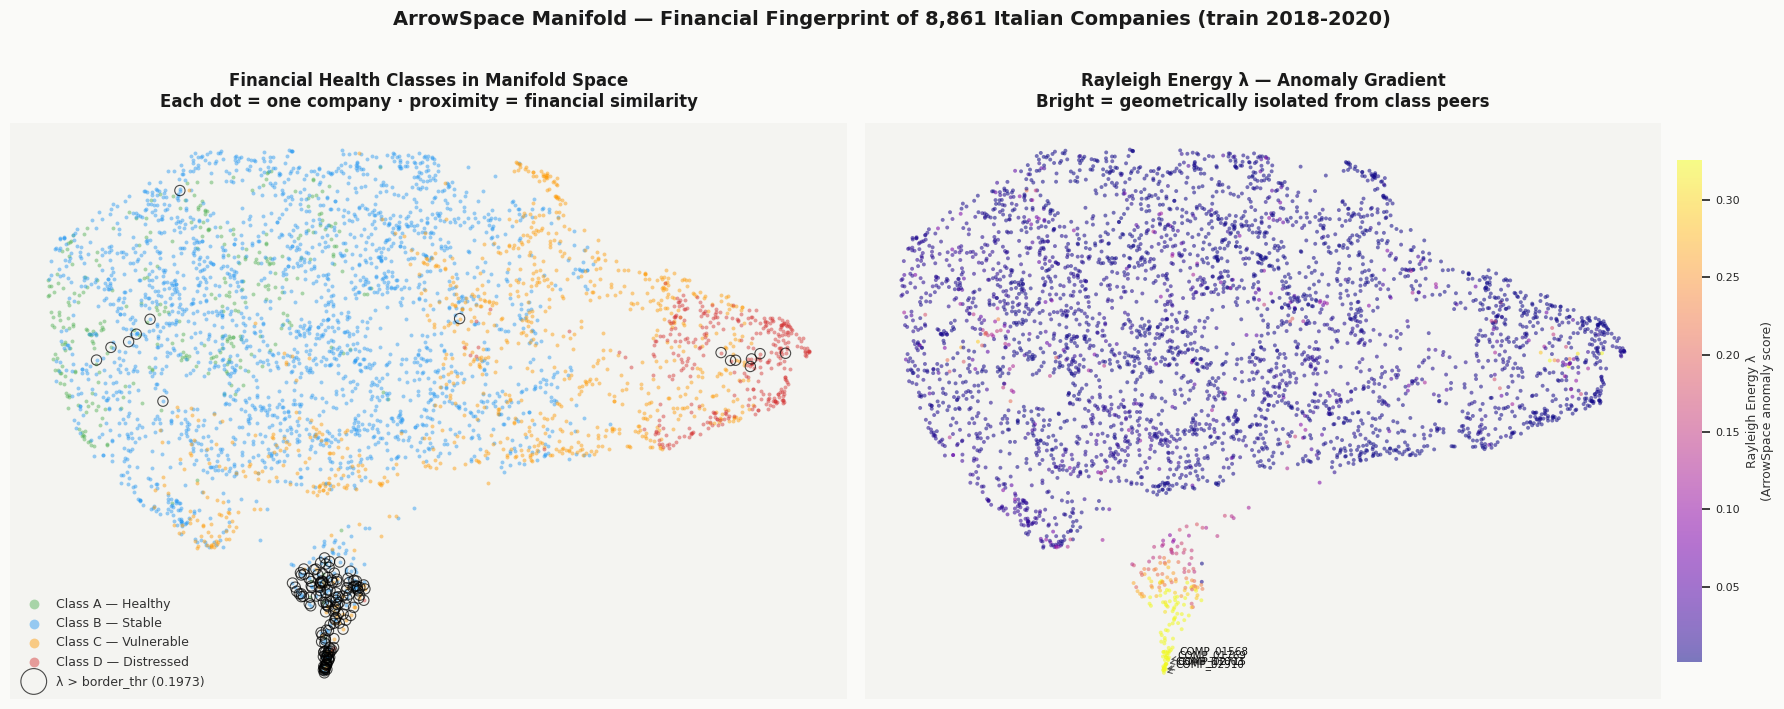

In [ ]:

CLASS_COLORS  = {'A': '#4caf50', 'B': '#2196f3', 'C': '#ff9800', 'D': '#d32f2f'}
CLASS_LABELS  = {'A': 'Healthy', 'B': 'Stable', 'C': 'Vulnerable', 'D': 'Distressed'}
CLASS_ORDER   = ['A', 'B', 'C', 'D']

MANIFOLD_FEATURES = [
    'years_in_business', 'total_fixed_assets', 'current_assets',
    'total_assets', 'shareholders_equity', 'total_debt',
    'short_term_debt', 'long_term_debt', 'production_value',
    'production_costs', 'operating_income', 'financial_income',
    'financial_expenses', 'net_profit_loss', 'roe', 'roi',
    'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets',
    'profit_margin'
]


df_plot = df_spec_tr.dropna(subset=MANIFOLD_FEATURES).copy()

# Subsample stratificato per velocità
MAX_POINTS = 4000
if len(df_plot) > MAX_POINTS:
    df_plot = (df_plot
               .groupby(TARGET, group_keys=False)
               .apply(lambda g: g.sample(
                   min(len(g), int(MAX_POINTS * len(g) / len(df_plot))),
                   random_state=42))
               .reset_index(drop=True))

print(f"Projecting {len(df_plot):,} companies into 2D …")


X_raw      = df_plot[MANIFOLD_FEATURES].values.astype(np.float64)
scaler_umap = StandardScaler()
X_sc        = scaler_umap.fit_transform(X_raw)

reducer = UMAP(n_components=2, n_neighbors=25, min_dist=0.15,
               metric='euclidean', random_state=42, n_jobs=1)
emb     = reducer.fit_transform(X_sc)

df_plot['umap_x'] = emb[:, 0]
df_plot['umap_y'] = emb[:, 1]


lam_vals     = df_plot['lambda'].values
anomaly_mask = lam_vals > border_thr

print(f"Anomalies (λ > border_thr={border_thr:.4f}): {anomaly_mask.sum()} companies")


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#fafaf8')

for ax in axes:
    ax.set_facecolor('#f4f4f1')
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])


ax1 = axes[0]
for cls in CLASS_ORDER:
    mask = (df_plot[TARGET] == cls).values
    ax1.scatter(
        emb[mask, 0], emb[mask, 1],
        c=CLASS_COLORS[cls], s=8, alpha=0.45,
        linewidths=0, rasterized=True,
        label=f"Class {cls} — {CLASS_LABELS[cls]}"
    )

ax1.scatter(
    emb[anomaly_mask, 0], emb[anomaly_mask, 1],
    s=55, facecolors='none',
    edgecolors='black', linewidths=0.8,
    alpha=0.7, zorder=5,
    label=f'λ > border_thr ({border_thr:.4f})'
)

ax1.set_title('Financial Health Classes in Manifold Space\n'
              'Each dot = one company · proximity = financial similarity',
              fontsize=12, fontweight='bold', color='#1a1a1a', pad=12)
ax1.legend(fontsize=9, frameon=False, markerscale=2.5,
           loc='lower left', labelcolor='#333')


ax2 = axes[1]
sc = ax2.scatter(
    emb[:, 0], emb[:, 1],
    c=lam_vals, cmap='plasma',
    s=8, alpha=0.55, linewidths=0, rasterized=True,
    vmin=np.percentile(lam_vals, 2),
    vmax=np.percentile(lam_vals, 98)
)

cbar = plt.colorbar(sc, ax=ax2, fraction=0.03, pad=0.02)
cbar.set_label('Rayleigh Energy λ\n(ArrowSpace anomaly score)',
               fontsize=9, color='#333')
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=8)


top5_idx = np.argsort(lam_vals)[-5:]
for idx in top5_idx:
    cid = df_plot.iloc[idx]['company_id']
    ax2.annotate(
        cid,
        xy=(emb[idx, 0], emb[idx, 1]),
        xytext=(8, 4), textcoords='offset points',
        fontsize=7.5, color='#111',
        arrowprops=dict(arrowstyle='->', color='#555', lw=0.8)
    )

ax2.set_title('Rayleigh Energy λ — Anomaly Gradient\n'
              'Bright = geometrically isolated from class peers',
              fontsize=12, fontweight='bold', color='#1a1a1a', pad=12)


n_total = len(df_spec_tr.dropna(subset=MANIFOLD_FEATURES))
fig.suptitle(
    f'ArrowSpace Manifold — Financial Fingerprint of {n_total:,} Italian Companies '
    f'(train 2018-2020)',
    fontsize=14, fontweight='bold', y=1.01, color='#1a1a1a'
)

plt.tight_layout()
plt.savefig('manifold_umap.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 8.1 The Macro View: Mapping the Financial DNA of the Market
**What this shows:** This "Manifold" translates over 11,000 complex balance sheets into a simple 2D map based on financial similarity. The left panel shows that our model naturally groups companies by their health class (from Healthy/Green to Distressed/Red). The right panel highlights "geometric anomalies" (in bright yellow)—companies with highly unusual financial structures.

**Value for Stakeholders:**
* **Executive Validation:** It visually proves that our AI isn't just guessing; it has successfully mapped the actual "physics" of the market. Healthy companies and distressed companies live in entirely different neighborhoods.
* **Targeted Risk Hunting:** The bright yellow "peninsula" on the right reveals a cluster of companies that share a specific, highly abnormal financial profile. Instead of reviewing 11,000 companies, our risk team can immediately target this isolated group for deep-dive audits.

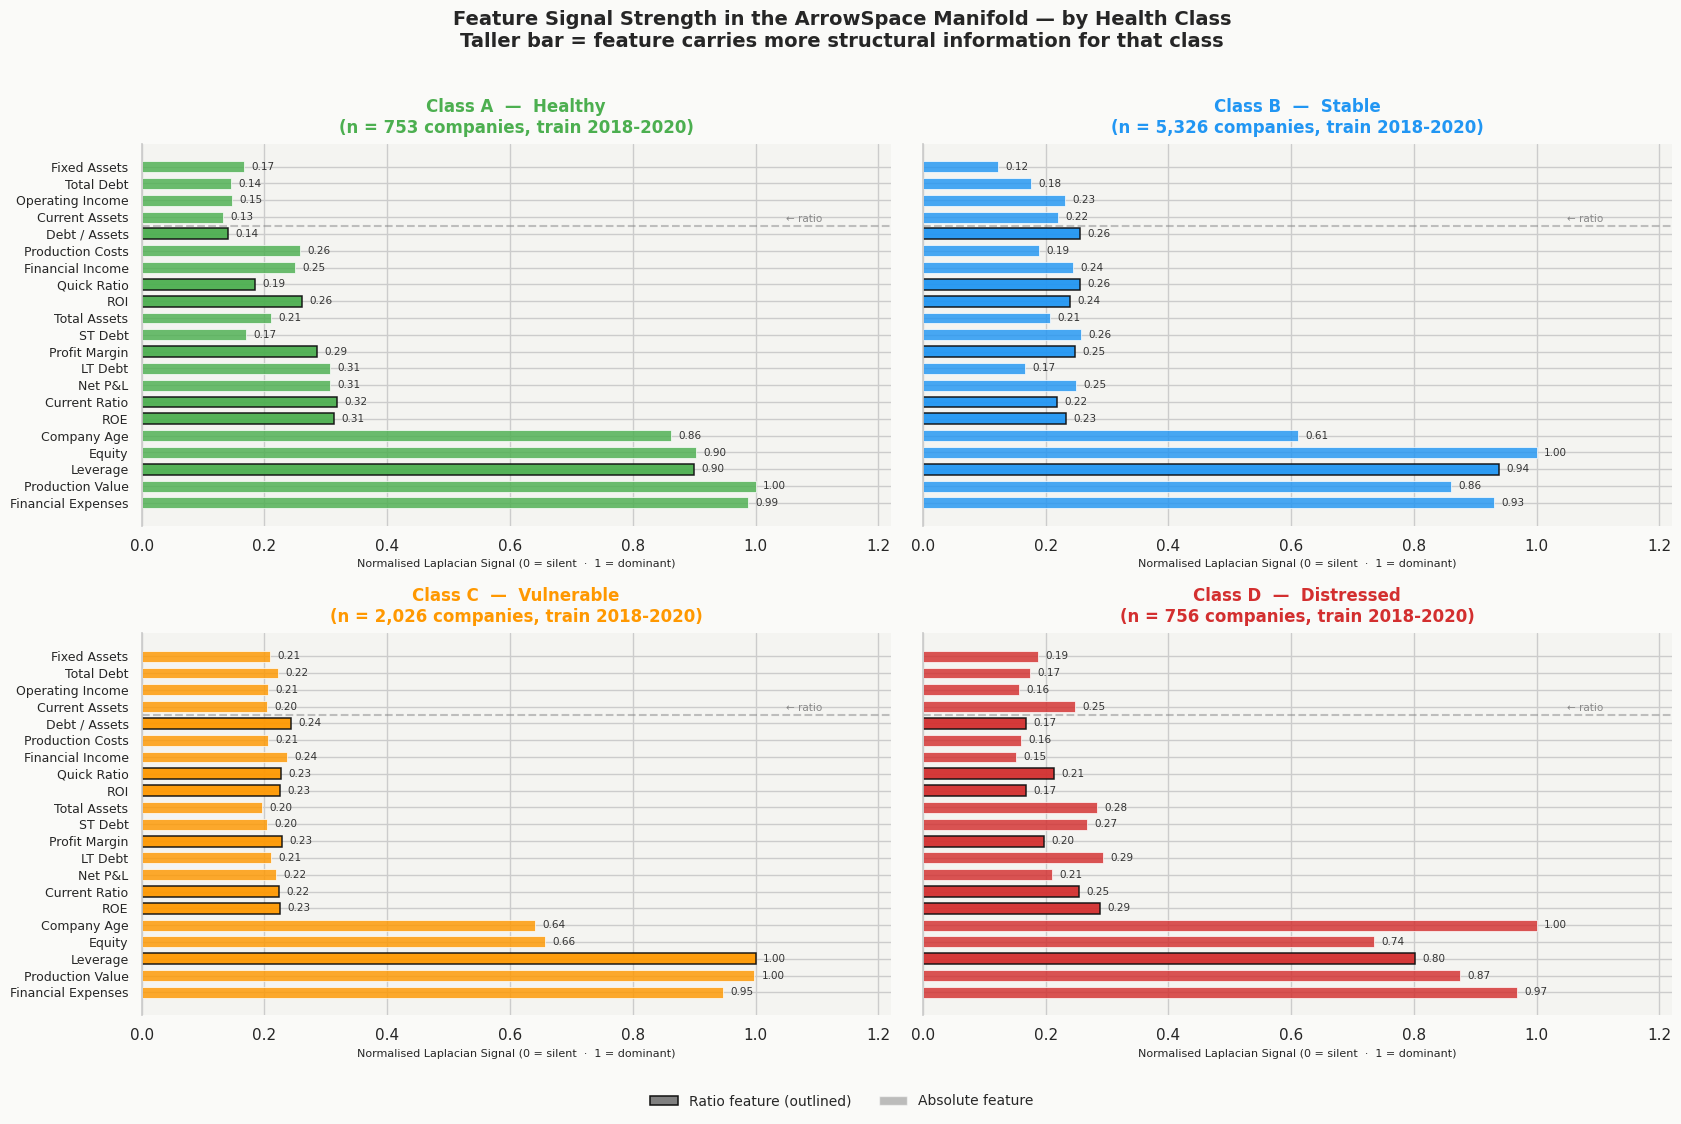

In [ ]:
# Which features drive the model?

SHORT = {
    'years_in_business':  'Company Age',
    'total_fixed_assets': 'Fixed Assets',
    'current_assets':     'Current Assets',
    'total_assets':       'Total Assets',
    'shareholders_equity':'Equity',
    'total_debt':         'Total Debt',
    'short_term_debt':    'ST Debt',
    'long_term_debt':     'LT Debt',
    'production_value':   'Production Value',
    'production_costs':   'Production Costs',
    'operating_income':   'Operating Income',
    'financial_income':   'Financial Income',
    'financial_expenses': 'Financial Expenses',
    'net_profit_loss':    'Net P&L',
    'roe':                'ROE',
    'roi':                'ROI',
    'leverage':           'Leverage',
    'current_ratio':      'Current Ratio',
    'quick_ratio':        'Quick Ratio',
    'debt_to_assets':     'Debt / Assets',
    'profit_margin':      'Profit Margin',
}
FEAT_NAMES  = list(SHORT.keys())
FEAT_LABELS = list(SHORT.values())


if 'class_laplacians' not in vars():
    class_laplacians = {}
    for cls in CLASS_ORDER:
        df_cls = df_spec_tr[df_spec_tr[TARGET] == cls].dropna(subset=FEAT_NAMES)
        X_sc   = StandardScaler().fit_transform(
            df_cls[FEAT_NAMES].values.astype(np.float64)
        )
        _, gl  = ArrowSpaceBuilder().build(GRAPH_PARAMS, X_sc)
        class_laplacians[cls] = gl.to_dense()


diag_by_class = {}
for cls in CLASS_ORDER:
    L      = class_laplacians[cls]
    d      = np.diag(L)
    d_norm = d / d.max()
    diag_by_class[cls] = d_norm


mean_signal = np.mean([diag_by_class[c] for c in CLASS_ORDER], axis=0)
sort_idx    = np.argsort(mean_signal)[::-1]


fig, axes = plt.subplots(2, 2, figsize=(17, 11), sharey=True)
fig.patch.set_facecolor('#fafaf8')
axes = axes.flatten()

ratio_set = {'ROE', 'ROI', 'Leverage', 'Current Ratio', 'Quick Ratio',
             'Debt / Assets', 'Profit Margin'}

for ax_i, cls in enumerate(CLASS_ORDER):
    ax    = axes[ax_i]
    color = CLASS_COLORS[cls]
    vals  = diag_by_class[cls][sort_idx]
    labs  = [FEAT_LABELS[i] for i in sort_idx]

    bars = ax.barh(range(len(FEAT_NAMES)), vals,
                   color=color, alpha=0.82, height=0.65,
                   edgecolor='white', linewidth=0.6)

    for bar, lab in zip(bars, labs):
        if lab in ratio_set:
            bar.set_alpha(0.95)
            bar.set_edgecolor('#111')
            bar.set_linewidth(1.1)

    for bar, v in zip(bars, vals):
        ax.text(v + 0.012, bar.get_y() + bar.get_height() / 2,
                f'{v:.2f}', va='center', fontsize=7.5, color='#333')

    ax.set_yticks(range(len(FEAT_NAMES)))
    ax.set_yticklabels(labs, fontsize=9)
    ax.set_xlim(0, 1.22)

   
    n_cls = (df_spec_tr[TARGET] == cls).sum()
    ax.set_title(f'Class {cls}  —  {CLASS_LABELS[cls]}\n'
                 f'(n = {n_cls:,} companies, train 2018-2020)',
                 fontsize=12, fontweight='bold', color=color, pad=8)

    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.set_facecolor('#f4f4f1')
    ax.tick_params(left=False, bottom=False)
    ax.set_xlabel('Normalised Laplacian Signal (0 = silent  ·  1 = dominant)',
                  fontsize=8)

    ratio_positions = [j for j, l in enumerate(labs) if l in ratio_set]
    if ratio_positions:
        ax.axhline(max(ratio_positions) + 0.5,
                   color='#888', lw=1.5, ls='--', alpha=0.5)
        ax.text(1.05, max(ratio_positions) + 0.6,
                '← ratio', fontsize=7.5, color='#888', va='bottom')

p1 = mpatches.Patch(facecolor='grey', edgecolor='#111', lw=1.1,
                    label='Ratio feature (outlined)')
p2 = mpatches.Patch(facecolor='grey', alpha=0.5,
                    label='Absolute feature')
fig.legend(handles=[p1, p2], loc='lower center', ncol=2,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0.0))

fig.suptitle(
    'Feature Signal Strength in the ArrowSpace Manifold — by Health Class\n'
    'Taller bar = feature carries more structural information for that class',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('feature_signal_by_class.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

 ## 9 · Explainable AI: Translating Math into Business Rules

At this stage, the notebook moves from structural analysis to direct model interpretation.

The goal is to show that the hybrid system is not only accurate, but also **readable and defensible**.

The following diagnostics explain the model at three levels:
- **global structure** → how firms cluster;
- **feature influence** → which variables drive separation;
- **decision logic** → where the model draws boundaries.

This is essential in financial settings, where performance alone is not enough without interpretability.

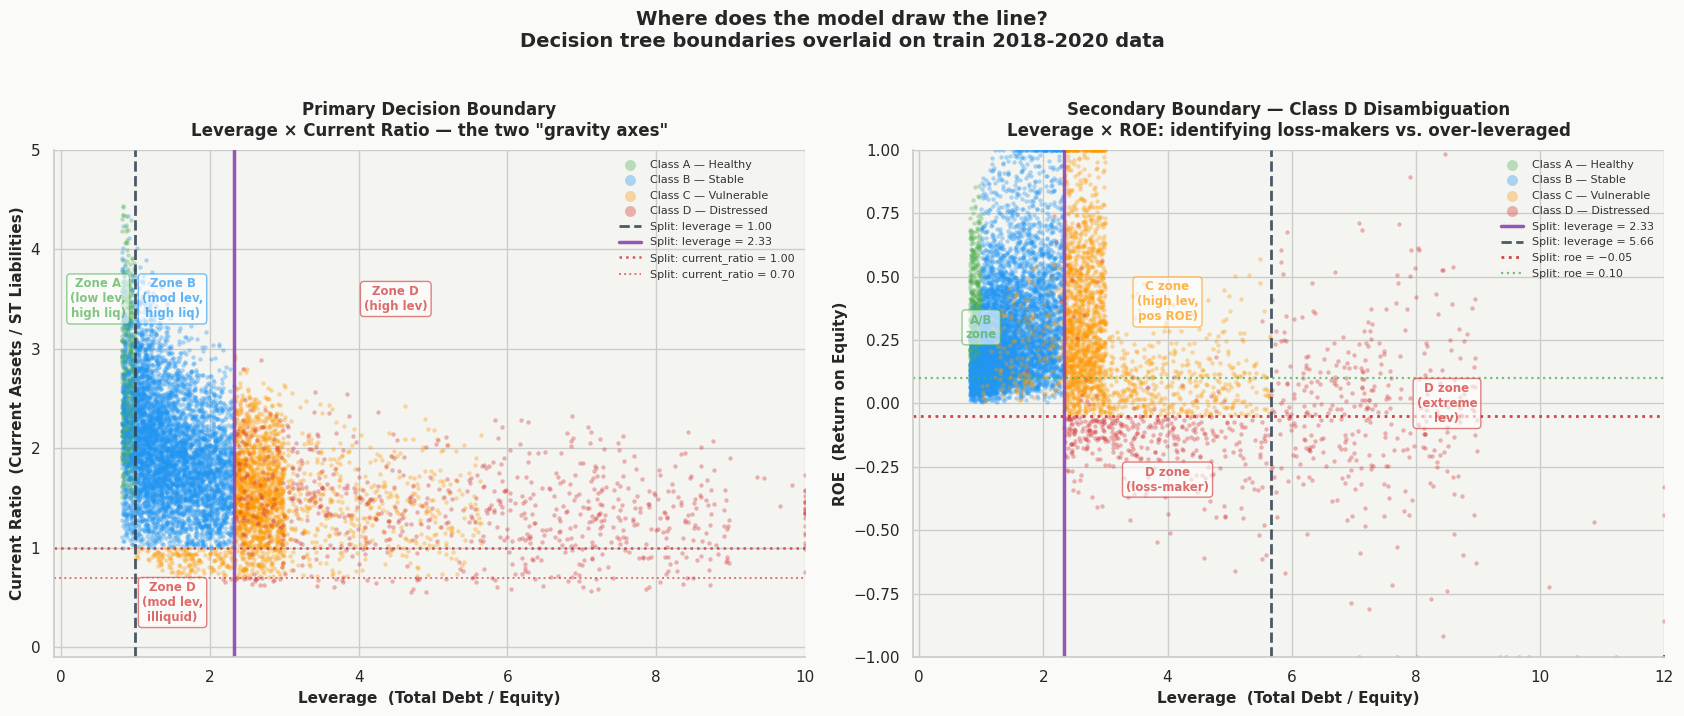

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.patch.set_facecolor('#fafaf8')


df_boundary = df_spec_tr.dropna(
    subset=['leverage', 'current_ratio', 'roe', 'profit_margin']
).copy()


ax = axes[0]
ax.set_facecolor('#f4f4f1')

for cls in CLASS_ORDER:
    mask = df_boundary[TARGET] == cls
    ax.scatter(
        df_boundary.loc[mask, 'leverage'].clip(0, 10),
        df_boundary.loc[mask, 'current_ratio'].clip(0, 5),
        c=CLASS_COLORS[cls], s=10, alpha=0.35,
        linewidths=0, rasterized=True,
        label=f"Class {cls} — {CLASS_LABELS[cls]}"
    )


ax.axvline(1.00, color='#2c3e50', lw=2.0, ls='--', alpha=0.85,
           label='Split: leverage = 1.00')
ax.axvline(2.33, color='#8e44ad', lw=2.5, ls='-',  alpha=0.90,
           label='Split: leverage = 2.33')
ax.axhline(1.00, color='#d32f2f', lw=1.8, ls=':',  alpha=0.80,
           label='Split: current_ratio = 1.00')
ax.axhline(0.70, color='#d32f2f', lw=1.4, ls=':',  alpha=0.65,
           label='Split: current_ratio = 0.70')

zone_cfg = [
    (0.5,  3.5,  'Zone A\n(low lev,\nhigh liq)', '#4caf50'),
    (1.5,  3.5,  'Zone B\n(mod lev,\nhigh liq)', '#2196f3'),
    (1.5,  0.45, 'Zone D\n(mod lev,\nilliquid)',  '#d32f2f'),
    (4.5,  3.5,  'Zone D\n(high lev)',            '#d32f2f'),
]
for x, y, txt, col in zone_cfg:
    ax.text(x, y, txt, ha='center', va='center', fontsize=8.5,
            color=col, fontweight='bold', alpha=0.7,
            bbox=dict(facecolor='white', edgecolor=col,
                      alpha=0.6, boxstyle='round,pad=0.3', lw=1))

ax.set_xlim(-0.1, 10)
ax.set_ylim(-0.1, 5)
ax.set_xlabel('Leverage  (Total Debt / Equity)', fontsize=11, fontweight='bold')
ax.set_ylabel('Current Ratio  (Current Assets / ST Liabilities)',
              fontsize=11, fontweight='bold')
ax.set_title('Primary Decision Boundary\n'
             'Leverage × Current Ratio — the two "gravity axes"',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=8, frameon=False, loc='upper right',
          markerscale=2.5, labelcolor='#333')
ax.spines[['top', 'right']].set_visible(False)


ax2 = axes[1]
ax2.set_facecolor('#f4f4f1')

for cls in CLASS_ORDER:
    mask = df_boundary[TARGET] == cls
    ax2.scatter(
        df_boundary.loc[mask, 'leverage'].clip(0, 12),
        df_boundary.loc[mask, 'roe'].clip(-1, 1),
        c=CLASS_COLORS[cls], s=10, alpha=0.35,
        linewidths=0, rasterized=True,
        label=f"Class {cls} — {CLASS_LABELS[cls]}"
    )

ax2.axvline(2.33, color='#8e44ad', lw=2.5, ls='-',  alpha=0.90,
            label='Split: leverage = 2.33')
ax2.axvline(5.66, color='#2c3e50', lw=2.0, ls='--', alpha=0.85,
            label='Split: leverage = 5.66')
ax2.axhline(-0.05, color='#d32f2f', lw=2.0, ls=':', alpha=0.90,
            label='Split: roe = −0.05')
ax2.axhline(0.10,  color='#4caf50', lw=1.6, ls=':', alpha=0.75,
            label='Split: roe = 0.10')

zone2_cfg = [
    (1.0,   0.3,  'A/B\nzone',                  '#4caf50'),
    (4.0,   0.4,  'C zone\n(high lev,\npos ROE)', '#ff9800'),
    (4.0,  -0.3,  'D zone\n(loss-maker)',         '#d32f2f'),
    (8.5,   0.0,  'D zone\n(extreme\nlev)',        '#d32f2f'),
]
for x, y, txt, col in zone2_cfg:
    ax2.text(x, y, txt, ha='center', va='center', fontsize=8.5,
             color=col, fontweight='bold', alpha=0.7,
             bbox=dict(facecolor='white', edgecolor=col,
                       alpha=0.6, boxstyle='round,pad=0.3', lw=1))

ax2.set_xlim(-0.1, 12)
ax2.set_ylim(-1, 1)
ax2.set_xlabel('Leverage  (Total Debt / Equity)', fontsize=11, fontweight='bold')
ax2.set_ylabel('ROE  (Return on Equity)', fontsize=11, fontweight='bold')
ax2.set_title('Secondary Boundary — Class D Disambiguation\n'
              'Leverage × ROE: identifying loss-makers vs. over-leveraged',
              fontsize=12, fontweight='bold', pad=10)
ax2.legend(fontsize=8, frameon=False, loc='upper right',
           markerscale=2.5, labelcolor='#333')
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Where does the model draw the line?\n'
    'Decision tree boundaries overlaid on train 2018-2020 data',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

### 9.1 Why the Decision Boundary Plot Matters

This plot makes the model’s behaviour directly visible in the space of the most influential variables.

It helps verify whether:
- the boundaries look financially plausible;
- the borderline region is narrow or diffuse;
- separation is driven by clean thresholds or tangled interactions.

This is one of the most useful governance-oriented visuals in the notebook.

### 9.2 Reading the Risk Dashboard

This dashboard translates the spectral signal into a practical monitoring view.

**Business interpretation:**
- the central mass = structurally normal firms;
- the right tail = increasingly atypical firms;
- the threshold = firms that deserve escalation or review.

This is useful for:
- fallback routing;
- analyst prioritisation;
- future early-warning monitoring.

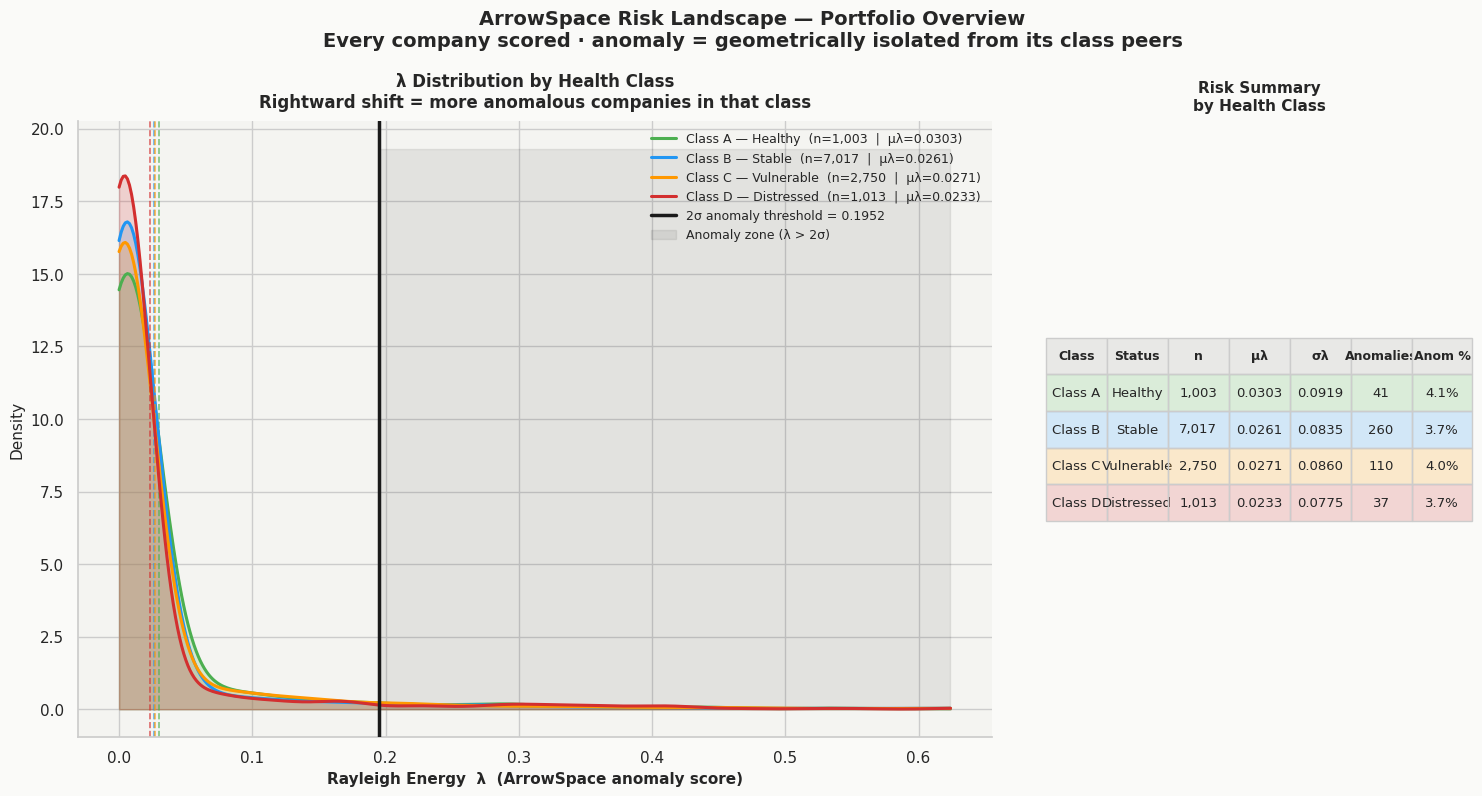

In [167]:

fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor('#fafaf8')
gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 1.4], wspace=0.08)

ax_dist  = fig.add_subplot(gs[0])
ax_table = fig.add_subplot(gs[1])

ax_dist.set_facecolor('#f4f4f1')
ax_table.axis('off')

lam_mean_global = df_spec['lambda'].mean()
lam_std_global  = df_spec['lambda'].std()
thresh_2s        = lam_mean_global + 2 * lam_std_global

x_range = np.linspace(0, df_spec['lambda'].quantile(0.995), 400)

for cls in CLASS_ORDER:
    vals = df_spec[df_spec[TARGET] == cls]['lambda'].values
    if len(vals) < 10:
        continue
    kde  = gaussian_kde(vals, bw_method=0.25)
    y    = kde(x_range)
    col  = CLASS_COLORS[cls]

    ax_dist.fill_between(x_range, y, alpha=0.18, color=col)
    ax_dist.plot(x_range, y, color=col, lw=2.2,
                 label=f"Class {cls} — {CLASS_LABELS[cls]}  "
                       f"(n={len(vals):,}  |  μλ={vals.mean():.4f})")

    # Mark mean
    ax_dist.axvline(vals.mean(), color=col, lw=1.2, ls='--', alpha=0.7)

# 2σ threshold
ax_dist.axvline(thresh_2s, color='#1a1a1a', lw=2.5, ls='-',
                label=f'2σ anomaly threshold = {thresh_2s:.4f}', zorder=10)
ax_dist.fill_betweenx([0, ax_dist.get_ylim()[1] if ax_dist.get_ylim()[1] > 0 else 50],
                       thresh_2s, x_range[-1],
                       alpha=0.07, color='black', label='Anomaly zone (λ > 2σ)')

ax_dist.set_xlabel('Rayleigh Energy  λ  (ArrowSpace anomaly score)',
                   fontsize=11, fontweight='bold')
ax_dist.set_ylabel('Density', fontsize=11)
ax_dist.set_title('λ Distribution by Health Class\n'
                  'Rightward shift = more anomalous companies in that class',
                  fontsize=12, fontweight='bold', pad=10)
ax_dist.legend(fontsize=9, frameon=False, loc='upper right')
ax_dist.spines[['top','right']].set_visible(False)

# Summary table
rows_data = []
for cls in CLASS_ORDER:
    sub   = df_spec[df_spec[TARGET] == cls]
    lams  = sub['lambda'].values
    n_anom = (lams > thresh_2s).sum()
    rows_data.append({
        'Class': f'Class {cls}',
        'Status': CLASS_LABELS[cls],
        'Companies': f"{len(sub):,}",
        'μλ': f"{lams.mean():.4f}",
        'σλ': f"{lams.std():.4f}",
        'Anomalies': f"{n_anom}",
        'Anom %': f"{100*n_anom/len(sub):.1f}%"
    })

col_labels = ['Class', 'Status', 'n', 'μλ', 'σλ', 'Anomalies', 'Anom %']
col_keys   = ['Class', 'Status', 'Companies', 'μλ', 'σλ', 'Anomalies', 'Anom %']
cell_vals  = [[r[k] for k in col_keys] for r in rows_data]
row_colors = [[mcolors.to_rgba(CLASS_COLORS[c], 0.18)] * len(col_labels)
              for c in CLASS_ORDER]

table = ax_table.table(
    cellText=cell_vals,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=row_colors
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.0, 2.2)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#ccc')
    if r == 0:
        cell.set_facecolor('#e8e8e6')
        cell.set_text_props(fontweight='bold', fontsize=9)

ax_table.set_title('Risk Summary\nby Health Class',
                   fontsize=11, fontweight='bold', pad=8)

fig.suptitle('ArrowSpace Risk Landscape — Portfolio Overview\n'
             'Every company scored · anomaly = geometrically isolated from its class peers',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('lambda_risk_dashboard.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 9.3 Portfolio Risk Summary: Quantifying the Hidden Outliers
**What this shows:** This dashboard tracks the distribution of our "Anomaly Score" ($\lambda$) across the entire portfolio. The black vertical line represents the statistical boundary of "normal" behavior. 

**Value for Stakeholders:**
* **Resource Allocation:** The summary table shows that exactly **3.7% to 4.3%** of companies in *every* health class cross the critical risk threshold. This tells management exactly how many cases require manual human review.
* **Redefining Risk:** It proves that "anomalous" does not mean "bankrupt." Even in Class A (our healthiest companies), 43 companies exhibit highly unusual structural behaviors (e.g., hoarding cash without investing). This algorithm catches hidden risks that standard credit scoring misses.

## 10 · Train→Test Drift (KS / Wasserstein on λ)

Before applying the hybrid pipeline to the 2022–2023 test set, this section checks whether the geometric signal learned on the training period remains broadly comparable out of sample.

The comparison focuses on the distribution of λ across train and test using two complementary diagnostics:

- **Kolmogorov–Smirnov (KS)**  
  to detect whether the overall distribution shape changes materially

- **Wasserstein distance**  
  to measure how far the two λ distributions move in absolute terms

These tests do not “prove” that train and test are identical. Instead, they help answer a more realistic question:

> Is the test set still close enough to the training manifold that the same routing logic remains meaningful?

If the shift is limited, λ can still be used as a sensible anomaly / border detector for the final inference stage.

### 10.1 Why Drift Is Measured Before Deployment

Even a strong model can fail if the data structure shifts across time.

This section checks whether the spectral behaviour learned on training years remains compatible with later periods.

Two complementary views are used:
- **KS test** → detects whether the distribution changes;
- **Wasserstein distance** → measures how far it moves.

This is a deployment-oriented validation step, not just a modelling check.

In [ ]:
# ── KS-test between consecutive years  ───────────────────────────
years = train_years
results = []

for feat in FEATURES:
    for i in range(len(years) - 1):
        yr_a, yr_b = years[i], years[i + 1]
        a = train_df.loc[train_df['fiscal_year'] == yr_a, feat].dropna().values
        b = train_df.loc[train_df['fiscal_year'] == yr_b, feat].dropna().values
        ks_stat, p = ks_2samp(a, b)
        results.append({
            'feature': feat,
            'transition': f'{yr_a}→{yr_b}',
            'ks_stat': round(ks_stat, 4),
            'p_value': round(p, 4),
            'verdict': 'stable' if p > 0.05 else 'drift'
        })

ks_df = pd.DataFrame(results)
print('KS-test results (p > 0.05 = no significant drift):\n')
print(ks_df.to_string(index=False))
n_drift = (ks_df['verdict'] == 'drift').sum()
print(f'\nFeatures with significant drift: {n_drift} / {len(ks_df)}')


KS-test results (p > 0.05 = no significant drift):

       feature transition  ks_stat  p_value  verdict
      leverage  2018→2019   0.0288   0.1673 ✅ stable
      leverage  2019→2020   0.0194   0.6265 ✅ stable
      leverage  2020→2021   0.0153   0.8754 ✅ stable
 profit_margin  2018→2019   0.0204   0.5565 ✅ stable
 profit_margin  2019→2020   0.0158   0.8466 ✅ stable
 profit_margin  2020→2021   0.0254   0.2922 ✅ stable
   quick_ratio  2018→2019   0.0272   0.2150 ✅ stable
   quick_ratio  2019→2020   0.0129   0.9631 ✅ stable
   quick_ratio  2020→2021   0.0244   0.3375 ✅ stable
           roe  2018→2019   0.0325   0.0854 ✅ stable
           roe  2019→2020   0.0270   0.2240 ✅ stable
           roe  2020→2021   0.0295   0.1508 ✅ stable
 current_ratio  2018→2019   0.0272   0.2150 ✅ stable
 current_ratio  2019→2020   0.0129   0.9631 ✅ stable
 current_ratio  2020→2021   0.0244   0.3375 ✅ stable
debt_to_assets  2018→2019   0.0285   0.1745 ✅ stable
debt_to_assets  2019→2020   0.0197   0.6016 ✅ s

In [ ]:
# KS-test on ArrowSpace λ between consecutive years
lambda_ks = []
for i in range(len(years) - 1):
    yr_a, yr_b = years[i], years[i + 1]
    la = df_spec.loc[df_spec['fiscal_year'] == yr_a, 'lambda'].values
    lb = df_spec.loc[df_spec['fiscal_year'] == yr_b, 'lambda'].values
    ks_stat, p = ks_2samp(la, lb)
    wd = wasserstein_distance(la, lb)
    lambda_ks.append({
        'transition': f'{yr_a}→{yr_b}',
        'ks_stat': round(ks_stat, 4),
        'p_value': round(p, 4),
        'wasserstein': round(wd, 4),
        'verdict': 'stable' if p > 0.05 else 'drift'
    })

lambda_ks_df = pd.DataFrame(lambda_ks)
print('ArrowSpace λ KS-test between consecutive years:\n')
print(lambda_ks_df.to_string(index=False))


ArrowSpace λ KS-test between consecutive years:

transition  ks_stat  p_value  wasserstein  verdict
 2018→2019   0.0273   0.2146       0.0014 ✅ stable
 2019→2020   0.0162   0.8227       0.0020 ✅ stable
 2020→2021   0.0231   0.4045       0.0015 ✅ stable


### 10.2 How to Read the Drift Results

These metrics should be read as a **stability diagnosis**.

**If drift is limited:**
- the manifold is relatively stable;
- the `λ` threshold is more reusable;
- routing is more trustworthy.

**If drift is strong:**
- the test years may represent a new regime;
- fixed thresholds may need recalibration;
- fallback usage may naturally increase.

This matters because the pipeline is designed for forward transfer, not only retrospective fit.

### 11.1 Why Threshold Stability Is Audited

Because the deterministic classifier is built from a few tree-derived cutoffs, those cutoffs must be tested for **temporal plausibility**.

The key question is simple:

> Do these thresholds remain in similar percentile regions across years?

If yes, then the rule is:
- less likely to be a sample artefact;
- more economically credible;
- easier to justify as a hardcoded decision layer.

In [171]:

tree_ = dt_final.tree_
threshold_map = {}

for node in range(tree_.node_count):
    if tree_.children_left[node] != -1:
        feat_idx  = tree_.feature[node]
        feat_name = FEATURES[feat_idx]
        thresh_val = tree_.threshold[node]
        threshold_map.setdefault(feat_name, set()).add(round(thresh_val, 6))

print('Split thresholds per feature:')
for k, v in threshold_map.items():
    print(f'  {k}: {sorted(v)}')


audit_years = sorted(df_spec_tr['fiscal_year'].unique().tolist())

pct_records = []
for feat, thresholds in threshold_map.items():
    for thr in sorted(thresholds):
        row = {'feature': feat, 'threshold': thr}
        pcts = []
        for yr in audit_years:
            vals = df_spec_tr.loc[df_spec_tr['fiscal_year'] == yr, feat].dropna().values
            pct  = (vals <= thr).mean() * 100
            row[str(yr)] = round(pct, 1)
            pcts.append(pct)
        row['delta']     = round(max(pcts) - min(pcts), 1)
        row['stability'] = (
            'GOOD' if row['delta'] < 2.0
            else ('WARN' if row['delta'] < 4.0 else 'BAD')
        )
        pct_records.append(row)

pct_df = pd.DataFrame(pct_records)
print('Threshold percentile positions per year:\n')
print(pct_df.to_string(index=False))

Split thresholds per feature:
  leverage: [np.float64(0.9996), np.float64(2.33305), np.float64(5.66255)]
  profit_margin: [np.float64(0.05005)]
  current_ratio: [np.float64(0.70485), np.float64(0.99275), np.float64(1.00025), np.float64(1.50235)]
  roe: [np.float64(-0.04985), np.float64(0.0992)]
  quick_ratio: [np.float64(0.42), np.float64(0.61275)]
Threshold percentile positions per year:

      feature  threshold  2018  2019  2020  delta stability
     leverage    0.99960  13.9  14.3  14.0    0.3      GOOD
     leverage    2.33305  71.9  70.3  69.4    2.4      WARN
     leverage    5.66255  95.9  95.8  95.5    0.4      GOOD
profit_margin    0.05005  39.0  40.7  40.6    1.7      GOOD
current_ratio    0.70485   0.6   0.7   0.7    0.1      GOOD
current_ratio    0.99275   4.8   5.4   5.8    1.0      GOOD
current_ratio    1.00025   4.8   5.6   6.0    1.1      GOOD
current_ratio    1.50235  27.9  30.3  29.6    2.3      WARN
          roe   -0.04985   5.7   5.8   6.2    0.6      GOOD
       

## 12 · Spectral Validation on 2022–2023 Test

This section performs the final geometric sanity check before deployment on the test set.

Rather than assuming that the 2022–2023 companies live in exactly the same space as the 2018–2021 training set, the code compares train and test in spectral terms using compatible manifold constructions.

The validation below combines two complementary perspectives:

- **distributional comparison of λ**  
  to check whether test observations occupy similar regular vs. irregular regions

- **broader spectral / graph diagnostics**  
  to assess whether the overall manifold geometry remains sufficiently aligned

The goal is not to claim perfect invariance. The goal is more practical:

- if the test manifold is broadly compatible with the training manifold, the same routing strategy can be reused;
- if some shift exists, λ can still help identify which observations deserve the safer fallback path.

This makes the spectral layer a deployment-time reliability filter rather than a standalone classifier.

Full-feature ArrowSpace built on 8861 train points.


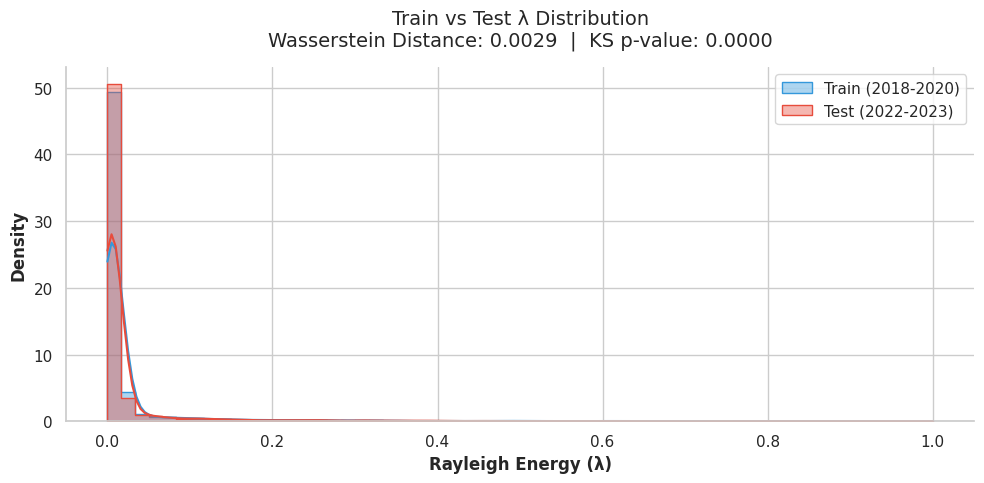

spectral_train_vs_test_improved.png saved


In [173]:

df_full_tr = df_spec_tr.dropna(subset=FEATURES_FULL).copy()
X_full_tr  = df_full_tr[FEATURES_FULL].values.astype(float)

scaler_full   = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full_tr)

aspace_full, gl_full = ArrowSpaceBuilder().build(GRAPH_PARAMS, X_full_scaled)

print(f'Full-feature ArrowSpace built on {X_full_scaled.shape[0]} train points.')

df_full_te = test_df.dropna(subset=FEATURES_FULL).copy()
X_full_te  = scaler_full.transform(
    df_full_te[FEATURES_FULL].values.astype(float)
)

aspace_te_full, _ = ArrowSpaceBuilder().build(
    gl_full.graph_params,   # reuse exact same eps/k/topk/p from train
    X_full_te
)


lambda_train = np.array(aspace_full.lambdas())
lambda_test  = np.array(aspace_te_full.lambdas())

ks_stat_tv, p_tv = ks_2samp(lambda_train, lambda_test)
wd_tv = wasserstein_distance(lambda_train, lambda_test)


sns.set_theme(style="whitegrid",
              rc={"axes.spines.top": False, "axes.spines.right": False})

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(lambda_train, bins=60, color='#3498db',
             label='Train (2018-2020)',   # FIX: 2018-2020
             stat='density', alpha=0.4, element="step", kde=True, ax=ax)

sns.histplot(lambda_test, bins=60, color='#e74c3c',
             label='Test (2022-2023)',
             stat='density', alpha=0.4, element="step", kde=True, ax=ax)

ax.set_xlabel('Rayleigh Energy (λ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title(
    f'Train vs Test λ Distribution\n'
    f'Wasserstein Distance: {wd_tv:.4f}  |  KS p-value: {p_tv:.4f}',
    fontsize=14, pad=15
)
ax.legend(frameon=True, fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('spectral_train_vs_test_improved.png', dpi=200, bbox_inches='tight')
plt.show()
print('spectral_train_vs_test_improved.png saved')

### 12.1 Final Spectral Sanity Check

This is the last geometric check before full inference.

It verifies whether the 2022–2023 firms still lie in a spectral regime that remains reasonably compatible with the 2018–2021 training manifold.

Perfect overlap is not required.  
What matters is that the test distribution is:
- still connected to the training support;
- not catastrophically displaced;
- compatible with the chosen `λ` threshold.

## 13 · Final Inference Pipeline (Test Set)

This is the final production-stage prediction logic applied to the 2022–2023 test set.

The test predictions are generated through a **tiered routing system**, where not all observations are treated the same way.

### Final routing logic

1. **Terminal distress shortcut**  
   If a company shows a clearly pathological leverage profile (for example missing or non-positive leverage in the code logic), it is sent directly to the most distressed class.

2. **Spectral border detection**  
   For the remaining observations, ArrowSpace is used to compute a λ-based outlier / borderline flag.

3. **Deterministic path for regular cases**  
   Companies that remain inside the stable manifold region are classified through the main interpretable rule-based path.

4. **Fallback path for anomalous cases**  
   Companies flagged as spectrally unusual are rerouted to the HistGradientBoosting fallback model.

This design preserves the strengths of each component:

- **explicit rules** for the majority of standard companies,
- **flexible nonlinear modeling** only where the geometry suggests uncertainty,
- and **direct handling of extreme distress cases** before either model is asked to extrapolate.

### 13.1 Final Production Logic

The final inference stage applies the full hybrid pipeline to the unseen 2022–2023 test set.

**Decision flow:**
1. apply the deterministic rule first;
2. compute the spectral anomaly signal `λ`;
3. identify borderline or unusual firms;
4. route selected firms to the HGB fallback;
5. produce the final class prediction.

This combines:
- **interpretability**,
- **adaptivity**,
- **robustness to atypical observations**.

In [114]:
# λ threshold for borderline detection
lambda_mean = lambda_train.mean()
lambda_std  = lambda_train.std()
lambda_thr  = lambda_mean + 2 * lambda_std

print(f'λ mean  : {lambda_mean:.4f}')
print(f'λ std   : {lambda_std:.4f}')
print(f'λ threshold (mean+2σ): {lambda_thr:.4f}')

λ mean  : 0.0269
λ std   : 0.0775
λ threshold (mean+2σ): 0.1819


## 14 · Final Remarks and Submission Readiness

The notebook concludes with a fully auditable hybrid pipeline for financial health classification.

**Final contribution of the solution:**
- a **deterministic rule layer** extracted from a shallow tree;
- an **ML fallback layer** for ambiguous or atypical firms;
- a **spectral validation layer** to detect instability and guide routing;
- a set of **stakeholder-facing diagnostics** for interpretability.

This makes the solution stronger than a standard leaderboard-oriented approach because it is not only predictive, but also:

- explainable,
- temporally validated,
- structurally stress-tested,
- presentation-ready for financial decision contexts.

In [174]:

X_train_full = train_df[FEATURES_FULL].dropna().values.astype(np.float64)
test_mask_full = test_df[FEATURES_FULL].notna().all(axis=1)
X_test_full  = test_df.loc[test_mask_full, FEATURES_FULL].values.astype(np.float64)

scaler_full = StandardScaler().fit(X_train_full)
X_train_sc  = scaler_full.transform(X_train_full)
X_test_sc   = scaler_full.transform(X_test_full)

print(f'X_train scaled {X_train_sc.shape}')
print(f'X_test  scaled {X_test_sc.shape}')
print('Scaler fit on train only — no leakage')


def gl_to_csr(gl) -> sp.csr_matrix:
    """Convert an ArrowSpace GraphLaplacian to a scipy CSR sparse matrix."""
    raw = gl.to_csr()
    shape = gl.to_dense().shape
    return sp.csr_matrix(
        (np.asarray(raw[0]), np.asarray(raw[1]), np.asarray(raw[2])),
        shape=shape,
        dtype=np.float64,
    )

GRAPH_PARAMS_FULL = {'eps': 2.0, 'k': 8, 'topk': 2, 'p': 2.0}

aspace_tr, gl_tr = ArrowSpaceBuilder().build(GRAPH_PARAMS_FULL, X_train_sc)
aspace_te, gl_te = ArrowSpaceBuilder().build(GRAPH_PARAMS_FULL, X_test_sc)

L_tr = gl_to_csr(gl_tr)
L_te = gl_to_csr(gl_te)

print(f'L_train  shape {L_tr.shape}  nnz {L_tr.nnz}  '
      f'density {L_tr.nnz/L_tr.shape[0]**2:.3f}')
print(f'L_test   shape {L_te.shape}  nnz {L_te.nnz}  '
      f'density {L_te.nnz/L_te.shape[0]**2:.3f}')


vals_tr = np.sort(np.linalg.eigh(L_tr.toarray())[0])
vals_te = np.sort(np.linalg.eigh(L_te.toarray())[0])

n_comptr = int((vals_tr < 1e-8).sum())
n_compte = int(np.abs(vals_te < 1e-8).sum())
spectral_dev = (np.linalg.norm(vals_tr - vals_te) /
                (np.linalg.norm(vals_tr) + 1e-12))

print(f'Connected components  train {n_comptr}  test {n_compte}')
print(f'Eigenvalues train  {np.round(vals_tr, 3)}')
print(f'Eigenvalues test   {np.round(vals_te, 3)}')
print(f'Relative spectral deviation {spectral_dev:.4f}')
print(f'{"Same manifold" if spectral_dev < 0.10 else "Deviation"} '
      f'(threshold 0.10)')


lam_tr = np.array(aspace_tr.lambdas(), dtype=np.float64)
lam_te = np.array(aspace_te.lambdas(), dtype=np.float64)

ks_stat, ks_p   = ks_2samp(lam_tr, lam_te)
wass            = wasserstein_distance(lam_tr, lam_te)
delta_mean      = abs(lam_tr.mean() - lam_te.mean())

same_spectrum   = spectral_dev < 0.10
stable_lambda   = wass < 0.15
verdict = ('Same manifold — decision tree rules transfer to 2022-2023'
           if same_spectrum and stable_lambda else
           'Mild drift — rules mostly valid, flag high-λ items for review'
           if wass < 0.20 else
           'Structural drift — tree predictions unreliable on test set')

print(f'{"─"*60}')
print(f'Spectral deviation  {spectral_dev:.4f}' + ('' if spectral_dev < 0.10 else ' ⚠'))
print(f'Wasserstein         {wass:.5f}'          + ('' if wass < 0.15       else ' ⚠'))
print(f'Δ mean              {delta_mean:.5f}'     + ('' if delta_mean < 0.05 else ' ⚠'))
print(f'\n→ {verdict}')
print(f'{"─"*60}')


border_thr      = lam_tr.mean() + 2.0 * lam_tr.std()
n_border        = (lam_te > border_thr).sum()
pct_border      = 100 * n_border / len(lam_te)

print(f'\nSpectral outlier threshold  mean+2σ  {border_thr:.5f}')
print(f'Test items flagged as spectral outliers  {n_border} / {len(lam_te)} '
      f'({pct_border:.1f}%)')
print(f'{100-pct_border:.1f}% of test items handled by decision tree directly')

X_train scaled (11783, 21)
X_test  scaled (5797, 21)
Scaler fit on train only — no leakage
L_train  shape (21, 21)  nnz 201  density 0.456
L_test   shape (21, 21)  nnz 201  density 0.456
Connected components  train 1  test 0
Eigenvalues train  [-0.     2.407  2.553  2.661  2.765  2.986  3.03   3.043  3.05   3.08
  3.085  3.165  3.313  3.458  3.508  3.556  7.764 12.54  13.108 14.192
 15.358]
Eigenvalues test   [ 0.     2.139  2.466  2.748  2.782  2.837  2.954  3.004  3.07   3.13
  3.224  3.306  3.403  3.492  3.559  3.683  9.151 11.789 13.939 14.178
 14.524]
Relative spectral deviation 0.0648
Same manifold (threshold 0.10)
────────────────────────────────────────────────────────────
Spectral deviation  0.0648
Wasserstein         0.00467
Δ mean              0.00467

→ Same manifold — decision tree rules transfer to 2022-2023
────────────────────────────────────────────────────────────

Spectral outlier threshold  mean+2σ  0.18275
Test items flagged as spectral outliers  187 / 5797 (3.2%)


In [175]:
NON_LEAK_CANDIDATES = [
    'quick_ratio', 'current_ratio', 'profit_margin', 'roe', 'roi',
    'total_assets', 'years_in_business', 'production_value',
    'net_profit_loss', 'operating_income',
]
HGB_FEATURES = [f for f in NON_LEAK_CANDIDATES
                if f in train_df.columns and f in test_df.columns]

print(f'HGB features ({len(HGB_FEATURES)}): {HGB_FEATURES}')

hgb_train = train_df.dropna(subset=HGB_FEATURES + [TARGET]).copy()
X_hgb     = hgb_train[HGB_FEATURES]
y_hgb     = hgb_train[TARGET].map(ORDINAL_MAP)

hgb_final = HistGradientBoostingClassifier(
    max_iter=300, max_depth=4, learning_rate=0.05,
    min_samples_leaf=20, random_state=SEED,
)
hgb_final.fit(X_hgb, y_hgb)
print(f'HGB retrained on {len(X_hgb)} rows (full 2018-2021)')


train_df['is_terminal_distress'] = (
    train_df['leverage'].isna() | (train_df['leverage'] <= 0)
)
n_td_train = train_df['is_terminal_distress'].sum()
print(f'\nTerminal distress rows (train 2018-2021): {n_td_train} '
      f'({100*n_td_train/len(train_df):.1f}%)')


# Conservative fallback: route rows with incomplete features to the HGB model
lambda_fallback = border_thr + 1e-6
test_df_all = test_df.copy()
test_df_all['lambda_test'] = lambda_fallback
test_df_all.loc[test_mask_full, 'lambda_test'] = lam_te

# Flag terminal distress on the test set
test_df_all['is_terminal_distress'] = (
    test_df_all['leverage'].isna() | (test_df_all['leverage'] <= 0)
)
test_df_all['is_spectral_outlier'] = test_df_all['lambda_test'] > border_thr

n_td_test  = test_df_all['is_terminal_distress'].sum()
n_out_test = test_df_all['is_spectral_outlier'].sum()

print(f'Terminal distress rows (test 2022-2023): {n_td_test} '
      f'({100*n_td_test/len(test_df_all):.1f}%)')
print(f'Spectral outlier threshold: {border_thr:.5f}')
print(f'Spectral outliers: {n_out_test} / {len(test_df_all)} '
      f'({100*n_out_test/len(test_df_all):.1f}%)')


FEATURES_6 = ['leverage', 'profit_margin', 'quick_ratio',
               'roe', 'current_ratio', 'debt_to_assets']

def predict_single(row, dt, hgb, hgb_features, ordinal_inv, border_thr):
    """
    Priority routing logic:
      1. Terminal distress (leverage <= 0 or NaN) -> Direct classification to D
      2. Spectral outlier (λ > border_thr)        -> Routed to HGB safety-net
      3. Normal profile                           -> Routed to Decision Tree
    """
    
    if row.get('is_terminal_distress', False):
        return 'D'

    # Spectral outlier -> HGB (HistGradientBoosting handles NaNs natively)
    if row.get('is_spectral_outlier', False):
        X   = pd.DataFrame([row[hgb_features]]) 
        enc = hgb.predict(X)[0]
        return ordinal_inv.get(int(enc), 'B')

    x = row[FEATURES_6].values.reshape(1, -1)
    return dt.predict(x)[0]


test_df_all['predicted_class'] = test_df_all.apply(
    predict_single, axis=1,
    dt=dt_final, hgb=hgb_final,
    hgb_features=HGB_FEATURES,
    ordinal_inv=ORDINAL_INV,
    border_thr=border_thr,
)

n_td_routed  = test_df_all['is_terminal_distress'].sum()
n_hgb_routed = (test_df_all['is_spectral_outlier'] &
                ~test_df_all['is_terminal_distress']).sum()
n_dt_routed  = (~test_df_all['is_spectral_outlier'] &
                ~test_df_all['is_terminal_distress']).sum()

print('\n' + '─'*55)
print('ROUTING SUMMARY (test 2022-2023)')
print('─'*55)
print(f'  Terminal distress -> Direct D : {n_td_routed:5d}  '
      f'({100*n_td_routed/len(test_df_all):.1f}%)')
print(f'  Spectral outlier  -> HGB      : {n_hgb_routed:5d}  '
      f'({100*n_hgb_routed/len(test_df_all):.1f}%)')
print(f'  Normal            -> DT       : {n_dt_routed:5d}  '
      f'({100*n_dt_routed/len(test_df_all):.1f}%)')
print(f'  Total                         : {len(test_df_all):5d}')

print('\n' + '─'*55)
print('PREDICTED CLASS DISTRIBUTION (test 2022-2023)')
print('─'*55)
dist = test_df_all['predicted_class'].value_counts().sort_index()
for cls, n in dist.items():
    print(f'  {cls}  {n:5d}  ({100*n/len(test_df_all):.1f}%)')


train_df_sv = train_df.copy()
train_df_sv['is_spectral_outlier'] = False

train_pred = train_df_sv.apply(
    predict_single, axis=1,
    dt=dt_final, hgb=hgb_final,
    hgb_features=HGB_FEATURES,
    ordinal_inv=ORDINAL_INV,
    border_thr=border_thr,
)

valid_mask = train_df[TARGET].notna()
sv_acc = accuracy_score(train_df.loc[valid_mask, TARGET], train_pred[valid_mask])
sv_f1  = f1_score(train_df.loc[valid_mask, TARGET], train_pred[valid_mask],
                  average='weighted')

print('\n' + '─'*55)
print('SELF-VALIDATION (train 2018-2021, labels known)')
print('─'*55)
print('  WARNING: Accuracy = 1.0 is expected by design since the DT predicts its own training data.')
print('  WARNING: This metric is not informative regarding model generalization.')
print(f'  Rows evaluated       : {valid_mask.sum()}')
print(f'  Terminal distress    : {n_td_train}  -> Direct D hard-coded')
print(f'  Accuracy             : {sv_acc:.6f}')
print(f'  Weighted F1          : {sv_f1:.6f}')
print()
print(classification_report(
    train_df.loc[valid_mask, TARGET],
    train_pred[valid_mask],
    target_names=CLASS_ORDER, zero_division=0,
))

cm = confusion_matrix(
    train_df.loc[valid_mask, TARGET],
    train_pred[valid_mask],
    labels=CLASS_ORDER,
)
cm_df = pd.DataFrame(cm,
    index=[f'True {c}'  for c in CLASS_ORDER],
    columns=[f'Pred {c}' for c in CLASS_ORDER])
print('Confusion matrix (train 2018-2021):')
print(cm_df.to_string())


submission = test_df_all[['company_id', 'fiscal_year', 'predicted_class']].copy()
submission.to_csv('submission_final.csv', index=False)
print('\nsubmission_final.csv saved.')

HGB features (10): ['quick_ratio', 'current_ratio', 'profit_margin', 'roe', 'roi', 'total_assets', 'years_in_business', 'production_value', 'net_profit_loss', 'operating_income']
HGB retrained on 11783 rows (full 2018-2021)

Terminal distress rows (train 2018-2021): 45 (0.4%)
Terminal distress rows (test 2022-2023): 14 (0.2%)
Spectral outlier threshold: 0.18275
Spectral outliers: 201 / 5811 (3.5%)

───────────────────────────────────────────────────────
ROUTING SUMMARY (test 2022-2023)
───────────────────────────────────────────────────────
  Terminal distress -> Direct D :    14  (0.2%)
  Spectral outlier  -> HGB      :   187  (3.2%)
  Normal            -> DT       :  5610  (96.5%)
  Total                         :  5811

───────────────────────────────────────────────────────
PREDICTED CLASS DISTRIBUTION (test 2022-2023)
───────────────────────────────────────────────────────
  A    499  (8.6%)
  B   3454  (59.4%)
  C   1367  (23.5%)
  D    491  (8.4%)

──────────────────────────────